In [2]:
pip install "numpy==1.26.4" matplotlib --force-reinstall

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl.metadata (61 kB)
  Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp312-cp312-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached packaging-26.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pillow-12.2.0-cp312-cp312-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
Using cached numpy-1.26.4-cp312-cp312-win_amd64.whl (15.5 MB)
Using cached matplotlib-3.10.9-cp312-cp312-win_amd64.whl (8.2 MB)
Using

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.52.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 26.2 which is incompatible.
streamlit 1.32.0 requires pillow<11,>=7.1.0, but you have pillow 12.2.0 which is incompatible.

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'   # Windows
# plt.rcParams['font.family'] = 'AppleGothic'   # Mac이면 이걸로 교체
plt.rcParams['axes.unicode_minus'] = False       # 마이너스 기호 깨짐 방지

# 데이터 변수 확인

In [4]:
# ════════════════════════════════════════════════════
# [데이터 로드] Hillstrom MineThatData 이메일 마케팅 실험 데이터
# - 출처: Kevin Hillstrom (前 Nordstrom DB마케팅 VP)
# - 규모: 64,000명 / 변수: 12개
# - 실험: 랜덤 배정 A/B 테스트 (Mens/Womens/No E-Mail)
# ════════════════════════════════════════════════════
import pandas as pd
import numpy as np

df = pd.read_csv('hillstrom.csv')

print(df.shape)
print(df.dtypes)

df.describe()

(64000, 12)
recency              int64
history_segment     object
history            float64
mens                 int64
womens               int64
zip_code            object
newbie               int64
channel             object
segment             object
visit                int64
conversion           int64
spend              float64
dtype: object


,recency,history,mens,womens,newbie,visit,conversion,spend
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,0.551031,0.549719,0.502250,0.146781,0.009031,1.050908
std,3.507592,256.158608,0.497393,0.497526,0.499999,0.353890,0.094604,15.036448
min,1.000000,29.990000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,9.000000,325.657500,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,12.000000,3345.930000,1.000000,1.000000,1.000000,1.000000,1.000000,499.000000


In [5]:
# ════════════════════════════════════════════════════
# [EDA 1] 범주형 변수 고유값 확인
# - history_segment: 구매액 구간 (7개, ordinal)
# - zip_code: 지역 유형 (3개, nominal)
# - channel: 구매 채널 (3개, nominal)
# - segment: 실험 그룹 → treatment 변수로 변환 예정
# ════════════════════════════════════════════════════
for col in ['history_segment', 'zip_code','channel','segment']:
    print(f'[{col}]',df[col].unique())

[history_segment] ['2) $100 - $200' '3) $200 - $350' '5) $500 - $750' '1) $0 - $100'
 '6) $750 - $1,000' '4) $350 - $500' '7) $1,000 +']
[zip_code] ['Surburban' 'Rural' 'Urban']
[channel] ['Phone' 'Web' 'Multichannel']
[segment] ['Womens E-Mail' 'No E-Mail' 'Mens E-Mail']


#  결측치 확인

In [6]:
# ════════════════════════════════════════════════════
# [EDA 2] 결측치 확인
# Kevin Hillstrom이 공개용으로 정제한 데이터 → 결측치 없음
# → 별도 대체 작업 없이 전체 행 사용 가능
# ════════════════════════════════════════════════════
missing = df.isnull().sum()
missing_pct = (missing/len(df) *100).round(2)

pd.DataFrame({'결측 수': missing, '결측 비율(%)':missing_pct})

,결측 수,결측 비율(%)
recency,0,0.0
history_segment,0,0.0
history,0,0.0
mens,0,0.0
womens,0,0.0
zip_code,0,0.0
newbie,0,0.0
channel,0,0.0
segment,0,0.0
visit,0,0.0


In [7]:
import matplotlib.pyplot as plt

if missing.sum() == 0:
    print("결측치 없음 - 모든 변수 완전한 데이터")
else:
    missing_pct.plot(kind='barh', figsize=(8,5), color='steelblue')
    plt.title('결측치 비율(%)')
    plt.xlabel('%')
    plt.tight_layout()
    plt.show

결측치 없음 - 모든 변수 완전한 데이터


# Treatment / Control 비율 확인══════════

In [8]:
# ════════════════════════════════════════════════════
# [EDA 3] Treatment / Control 그룹 비율 확인
# - 세 그룹이 약 33.3%씩 균등 분배 → 랜덤 배정 성공
# - 그룹 간 feature 평균 동일 → Selection Bias 없음
#   → Uplift 인과효과 추정 신뢰 가능
# ════════════════════════════════════════════════════
print(df['segment'].value_counts())
print(df['segment'].value_counts(normalize=True).round(3))

segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64
segment
Womens E-Mail    0.334
Mens E-Mail      0.333
No E-Mail        0.333
Name: proportion, dtype: float64


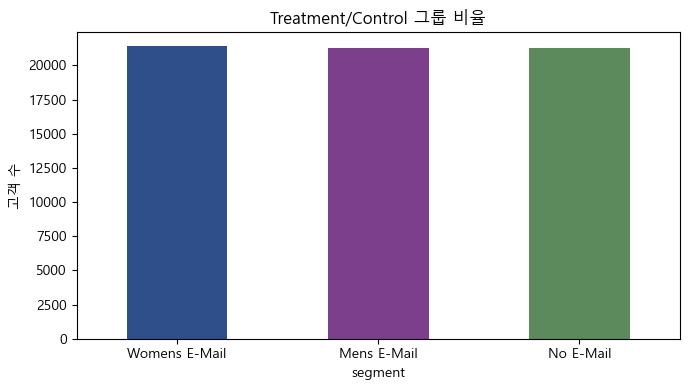

In [9]:
df['segment'].value_counts().plot(kind='bar', figsize=(7,4), color=['#2E4F8A','#7B3F8C','#5C8A5C'])
plt.title('Treatment/Control 그룹 비율')
plt.ylabel('고객 수')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [10]:
#랜덤 배정 균형 검증 - 그룹별 feature 평균이 비슷한지 확인
df.groupby('segment')[['recency','history','mens','womens','newbie']].mean().round(3)

,recency,history,mens,womens,newbie
segment,,,,,
Mens E-Mail,5.774,242.836,0.551,0.551,0.502
No E-Mail,5.750,240.883,0.553,0.548,0.502
Womens E-Mail,5.768,242.537,0.549,0.550,0.503


# 방문율 / 전환율 / 구매액 분포 확인

In [11]:
segs = ['Mens E-Mail','Womens E-Mail','No E-Mail']

for seg in segs:
    sub = df[df['segment'] == seg]
    print(f'\n[{seg}]')
    print(f'방문율 : {sub["visit"].mean()*100:.2f}%')
    print(f'전환율 : {sub["conversion"].mean()*100:.2f}%')
    print(f'평균 spend: ${sub["spend"].mean():.2f}')


[Mens E-Mail]
방문율 : 18.28%
전환율 : 1.25%
평균 spend: $1.42

[Womens E-Mail]
방문율 : 15.14%
전환율 : 0.88%
평균 spend: $1.08

[No E-Mail]
방문율 : 10.62%
전환율 : 0.57%
평균 spend: $0.65


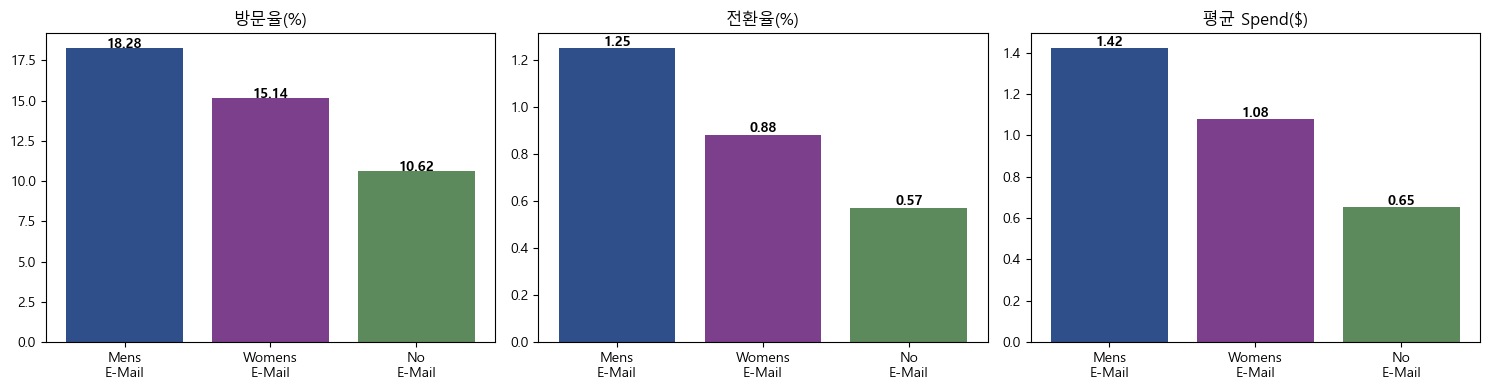

In [12]:
fig, axes = plt.subplots(1,3,figsize=(15,4))
colors = ['#2E4F8A', '#7B3F8C', '#5C8A5C']
labels = ['Mens\nE-Mail','Womens\nE-Mail','No\nE-Mail']

metrics = {
    '방문율(%)': [df[df['segment']==s]['visit'].mean()*100 for s in segs],
    '전환율(%)': [df[df['segment']==s]['conversion'].mean()*100 for s in segs],
    '평균 Spend($)': [df[df['segment']==s]['spend'].mean() for s in segs],
}
for ax, (title, vals) in zip(axes, metrics.items()):
    bars = ax.bar(labels, vals, color=colors)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() +0.01,
                f'{v:.2f}',ha='center',fontweight='bold')
    ax.set_title(title)

plt.tight_layout()
plt.show()

C:\Users\iskk1\AppData\Local\Temp\ipykernel_36760\2156475.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_box, labels=labels, patch_artist=True,


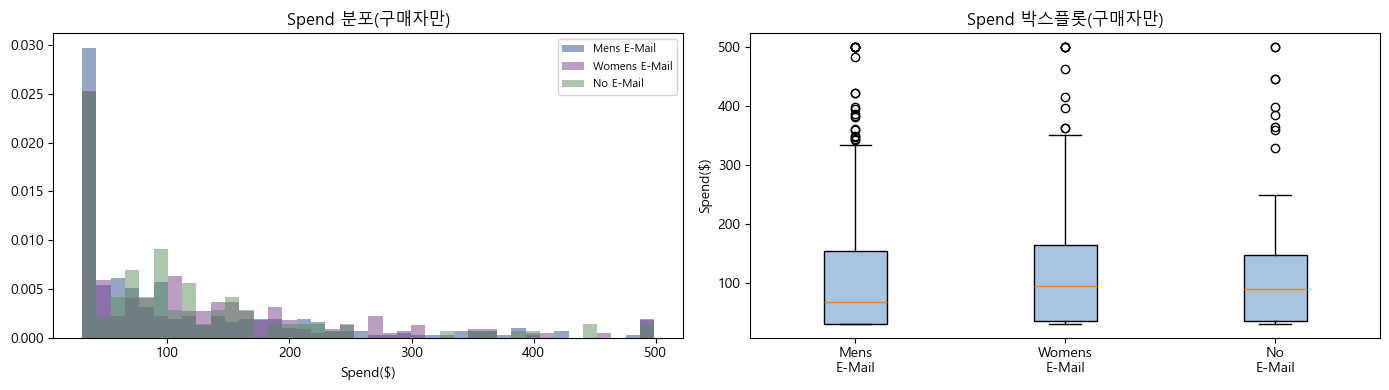

In [13]:
fig, axes = plt.subplots(1,2,figsize=(14,4))

for seg, col in zip(segs, colors):
    data = df[(df['segment']==seg)&(df['spend']>0)]['spend']
    axes[0].hist(data, bins=40, alpha=0.5, color=col, label=seg, density=True)

axes[0].set_title('Spend 분포(구매자만)')
axes[0].set_xlabel('Spend($)')
axes[0].legend(fontsize=8)

data_box = [df[(df['segment']==s)&(df['spend']>0)]['spend'].values for s in segs]
axes[1].boxplot(data_box, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='#A8C4E0'))
axes[1].set_title('Spend 박스플롯(구매자만)')
axes[1].set_ylabel('Spend($)')

plt.tight_layout()
plt.show()

# 주요 Feature와 Outcome의 관계 확인

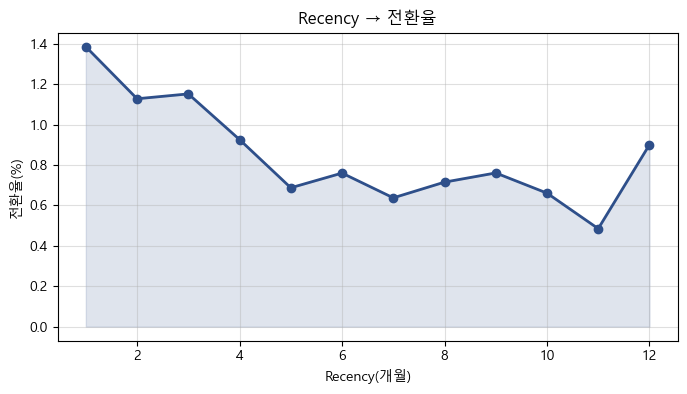

In [14]:
rec_conv = df.groupby('recency')['conversion'].mean()*100

plt.figure(figsize=(8,4))
plt.plot(rec_conv.index, rec_conv.values, 'o-',color='#2E4F8A', linewidth=2)
plt.fill_between(rec_conv.index, rec_conv.values, alpha=0.15, color='#2E4F8A')
plt.title('Recency → 전환율')
plt.xlabel('Recency(개월)')
plt.ylabel('전환율(%)')
plt.grid(alpha=0.4)
plt.show()

['1) $0 - $100', '2) $100 - $200', '3) $200 - $350', '4) $350 - $500', '5) $500 - $750', '6) $750 - $1,000', '7) $1,000 +']


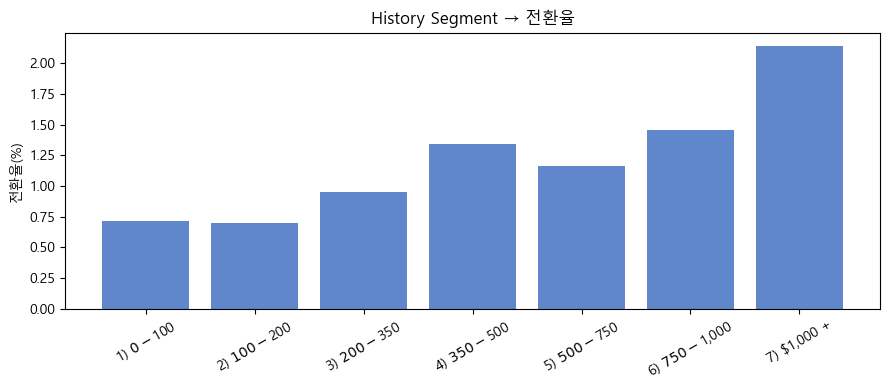

In [15]:
#history_segment → 전환율
hs_order = sorted(df['history_segment'].unique())
print(hs_order)

hs_conv = [df[df['history_segment']==h]['conversion'].mean()*100 for h in hs_order]

plt.figure(figsize=(9,4))
plt.bar(range(len(hs_order)),hs_conv, color='#4472C4', alpha=0.85)
plt.xticks(range(len(hs_order)), hs_order, rotation=30)
plt.title('History Segment → 전환율')
plt.ylabel('전환율(%)')
plt.tight_layout()
plt.show()

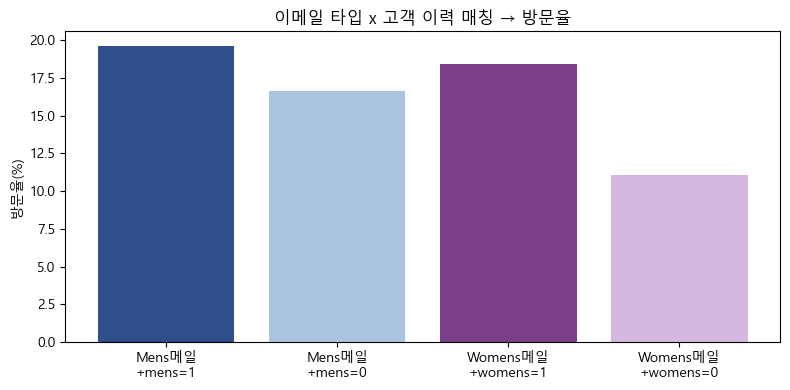

In [16]:
# mens/womens 이메일 매칭 효과
combos = {
    'Mens메일\n+mens=1':     df[(df['segment']=='Mens E-Mail')   & (df['mens']==1)]['visit'].mean()*100,
    'Mens메일\n+mens=0':     df[(df['segment']=='Mens E-Mail')   & (df['mens']==0)]['visit'].mean()*100,
    'Womens메일\n+womens=1': df[(df['segment']=='Womens E-Mail') & (df['womens']==1)]['visit'].mean()*100,
    'Womens메일\n+womens=0': df[(df['segment']=='Womens E-Mail') & (df['womens']==0)]['visit'].mean()*100,
}

plt.figure(figsize=(8,4))
plt.bar(combos.keys(), combos.values(),color=['#2E4F8A','#A8C4E0','#7B3F8C','#D4B8E0'])
plt.title('이메일 타입 x 고객 이력 매칭 → 방문율')
plt.ylabel('방문율(%)')
plt.tight_layout()
plt.show()

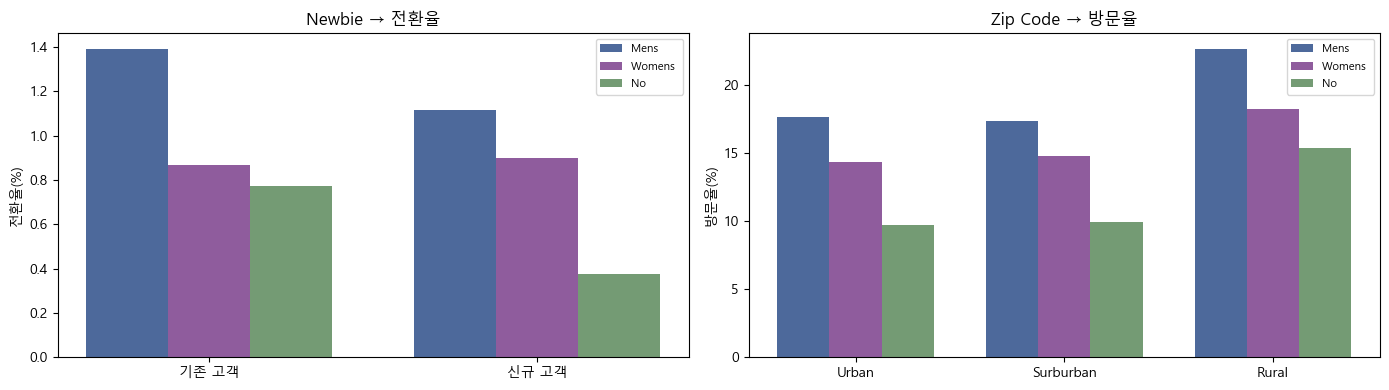

In [17]:
#newbie / zip_code -> 전환율
fig, axes = plt.subplots(1,2,figsize=(14,4))

#newbie
x = np.arange(2)
for i , (seg, col) in enumerate(zip(segs, colors)):
    rates = [df[(df['segment']==seg) & (df['newbie']==n)]['conversion'].mean()*100 for n in [0,1]]
    axes[0].bar(x+i*0.25, rates, width=0.25, color=col, alpha=0.85, label=seg.replace('E-Mail',''))
axes[0].set_xticks(x+0.25)
axes[0].set_xticklabels(['기존 고객','신규 고객'])
axes[0].set_title('Newbie → 전환율')
axes[0].set_ylabel('전환율(%)')
axes[0].legend(fontsize=8)

#zip_code
zips = ['Urban','Surburban','Rural']
x2 = np.arange(3)
for i, (seg, col) in enumerate(zip(segs, colors)):
    rates = [df[(df['segment']==seg) & (df['zip_code']==z)]['visit'].mean()*100 for z in zips]
    axes[1].bar(x2 + i*0.25, rates, width=0.25, color=col, alpha=0.85, label=seg.replace('E-Mail',''))
axes[1].set_xticks(x2 + 0.25)
axes[1].set_xticklabels(zips)
axes[1].set_title('Zip Code → 방문율')
axes[1].set_ylabel('방문율(%)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# 학습 Feature 정리(모델에 넣을 변수 정리)

In [18]:
df_model = df.copy()

#zip_code 오타 수정
df_model['zip_code'] = df_model['zip_code'].replace('Surburban', 'Suburban')

hs_order = {
    '1) $0 - $100'    : 1,
    '2) $100 - $200'  : 2,
    '3) $200 - $350'  : 3,
    '4) $350 - $500'  : 4,
    '5) $500 - $750'  : 5,
    '6) $750 - $1,000': 6,
    '7) $1,000 +'     : 7,
}
df_model['history_segment_enc']=df_model['history_segment'].map(hs_order)

df_model = pd.get_dummies(df_model, columns=['zip_code','channel'], drop_first=False)

print(df_model.columns.tolist())
print(df_model.shape)

['recency', 'history_segment', 'history', 'mens', 'womens', 'newbie', 'segment', 'visit', 'conversion', 'spend', 'history_segment_enc', 'zip_code_Rural', 'zip_code_Suburban', 'zip_code_Urban', 'channel_Multichannel', 'channel_Phone', 'channel_Web']
(64000, 17)


In [19]:
#최종 학습에 사용할 feature 목록
FEATURES = [
     'recency',              # ★★★ 핵심
    'history',              # ★★☆
    'history_segment_enc',  # ★★☆ (history 보완)
    'mens',                 # ★★★
    'womens',               # ★★★
    'newbie',               # ★★☆
    'zip_code_Urban',       # ★☆☆
    'zip_code_Suburban',    # ★☆☆
    'zip_code_Rural',       # ★☆☆
    'channel_Phone',        # ★☆☆
    'channel_Web',          # ★☆☆
    'channel_Multichannel', # ★☆☆
]

TARGET = 'conversion'#메인 타겟

print(f'학습 feature 수: {len(FEATURES)}개')
print(f'타겟 변수: {TARGET}')
df_model[FEATURES].describe()

학습 feature 수: 12개
타겟 변수: conversion


,recency,history,history_segment_enc,mens,womens,newbie
count,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000,64000.000000
mean,5.763734,242.085656,2.481969,0.551031,0.549719,0.502250
std,3.507592,256.158608,1.544514,0.497393,0.497526,0.499999
min,1.000000,29.990000,1.000000,0.000000,0.000000,0.000000
25%,2.000000,64.660000,1.000000,0.000000,0.000000,0.000000
50%,6.000000,158.110000,2.000000,1.000000,1.000000,1.000000
75%,9.000000,325.657500,3.000000,1.000000,1.000000,1.000000
max,12.000000,3345.930000,7.000000,1.000000,1.000000,1.000000


In [20]:
#feature 최종 정리표 출력
feature_summary = pd.DataFrame({
    'feature': FEATURES,
    'type': [
        'int', 'float', 'int(ordinal)',
        'binary', 'binary', 'binary',
        'dummy', 'dummy', 'dummy',
        'dummy', 'dummy', 'dummy'
    ],
    '중요도': [
        '★★★', '★★☆', '★★☆',
        '★★★', '★★★', '★★☆',
        '★☆☆', '★☆☆', '★☆☆',
        '★☆☆', '★☆☆', '★☆☆'
    ],
    '근거': [
        '최근 구매자 전환율 3배',
        '고액 구매 이력 → 재전환 높음',
        'EDA에서 우상향 패턴 확인',
        '이메일 매칭 효과 확인',
        '이메일 매칭 효과 확인',
        '기존 고객 전환율 일관되게 높음',
        'Rural 방문율 높으나 uplift 영향 낮음',
        'Rural 방문율 높으나 uplift 영향 낮음',
        'Rural 방문율 높으나 uplift 영향 낮음',
        '그룹 간 차이 미미',
        '그룹 간 차이 미미',
        '그룹 간 차이 미미',
    ]
})

print(feature_summary.to_string(index=False))

             feature         type 중요도                         근거
             recency          int ★★★              최근 구매자 전환율 3배
             history        float ★★☆          고액 구매 이력 → 재전환 높음
 history_segment_enc int(ordinal) ★★☆            EDA에서 우상향 패턴 확인
                mens       binary ★★★               이메일 매칭 효과 확인
              womens       binary ★★★               이메일 매칭 효과 확인
              newbie       binary ★★☆          기존 고객 전환율 일관되게 높음
      zip_code_Urban        dummy ★☆☆ Rural 방문율 높으나 uplift 영향 낮음
   zip_code_Suburban        dummy ★☆☆ Rural 방문율 높으나 uplift 영향 낮음
      zip_code_Rural        dummy ★☆☆ Rural 방문율 높으나 uplift 영향 낮음
       channel_Phone        dummy ★☆☆                 그룹 간 차이 미미
         channel_Web        dummy ★☆☆                 그룹 간 차이 미미
channel_Multichannel        dummy ★☆☆                 그룹 간 차이 미미


In [21]:
# Response Model용 → segment를 binary로
df_model['treatment_mens']   = (df_model['segment'] == 'Mens E-Mail').astype(int)
df_model['treatment_womens'] = (df_model['segment'] == 'Womens E-Mail').astype(int)
df_model['treatment']        = (df_model['segment'] != 'No E-Mail').astype(int)

# Uplift Model용 → treatment 0/1
# Mens만 분석할 경우
df_mens = df_model[df_model['segment'].isin(['Mens E-Mail', 'No E-Mail'])].copy()
df_mens['treatment'] = (df_mens['segment'] == 'Mens E-Mail').astype(int)

# Womens만 분석할 경우
df_womens = df_model[df_model['segment'].isin(['Womens E-Mail', 'No E-Mail'])].copy()
df_womens['treatment'] = (df_womens['segment'] == 'Womens E-Mail').astype(int)

print('Mens 데이터:', df_mens.shape)
print('Womens 데이터:', df_womens.shape)
print('\nTreatment 비율 (Mens):')
print(df_mens['treatment'].value_counts())

Mens 데이터: (42613, 20)
Womens 데이터: (42693, 20)

Treatment 비율 (Mens):
treatment
1    21307
0    21306
Name: count, dtype: int64


# 모델링

In [22]:
#공통 준비
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

#Mens 기준 진행(Womens도 동일 구조)
df_mens = df_model[df_model['segment'].isin(['Mens E-Mail','No E-Mail'])].copy()
df_mens['treatment'] = (df_mens['segment']=='Mens E-Mail').astype(int)

FEATURES = [
    'recency', 'history', 'history_segment_enc',
    'mens', 'womens', 'newbie',
    'zip_code_Urban', 'zip_code_Suburban', 'zip_code_Rural',
    'channel_Phone', 'channel_Web', 'channel_Multichannel'
]
TARGET = 'conversion'

X = df_mens[FEATURES]
Y = df_mens[TARGET]
T = df_mens['treatment']

X_train, X_test, y_train, y_test, T_train,T_test = train_test_split(
    X,Y,T,test_size=0.2, random_state=42, stratify=Y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'전환율(train):{y_train.mean()*100:.2f}%')

Train: (34090, 12), Test: (8523, 12)
전환율(train):0.91%


In [23]:
#Baseline - 전체 발송 : 모든 고객에게 이메일 발송 / 아무 모델 없이 무조건 send -> 전환율 = treatment 그룹 전환율
# - 아무 모델 없이 모든 고객에게 이메일 발송
# - 전환율 = treatment 그룹 전환율
# - Raw Uplift = 새로 만들 모델이 넘어야 할 기준선

baseline_conversion = df_mens[df_mens['treatment']==1][TARGET].mean()
baseline_spend = df_mens[df_mens['treatment']==1]['spend'].mean()
ctrl_conversion = df_mens[df_mens['treatment']==0][TARGET].mean()

print('===Baseline(전체 발송)===')
print(f'이메일 발송 그룹 전환율 : {baseline_conversion*100:.2f}%')
print(f'Control 그룹 전환율: {ctrl_conversion*100:.2f}%')
print(f'Raw Uplift: +{(baseline_conversion - ctrl_conversion)*100:.2f}%p')

===Baseline(전체 발송)===
이메일 발송 그룹 전환율 : 1.25%
Control 그룹 전환율: 0.57%
Raw Uplift: +0.68%p


In [24]:
# Response Model - Logistic Regression
#response Model : 구매확률 높은 고객 타겟 & treatment/control 구분 없이 전체로 학습
# - "구매할 확률이 높은 고객" 예측
# - treatment/control 구분 없이 전체 데이터로 학습
# - 한계: "원래 살 사람"도 타겟에 포함됨
#         → 이메일 효과와 무관한 고객에게도 발송

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

lr = LogisticRegression(class_weight='balanced', max_iter = 1000, random_state=42)
lr.fit(X_train_sc, y_train)

y_pred_lr = lr.predict_proba(X_test_sc)[:,1]

print('===Response Model: Logistic Regression===')
print(f'AUC:{roc_auc_score(y_test, y_pred_lr):.4f}')

===Response Model: Logistic Regression===
AUC:0.6621


In [25]:
# Response Model - Random Forest (비교용)
# - 클래스 불균형 처리: 다수 클래스 다운샘플링 (10:1)
# - AUC: 0.5225 → LR(0.6621)보다 낮아 참고용으로만 활용
# - Feature Importance 확인용: history, recency 압도적
# ════════════════════════════════════════════════════
from sklearn.utils import resample

df_train_bal = X_train.copy()
df_train_bal['conversion'] = y_train.values

majority = df_train_bal[df_train_bal['conversion']==0]
minority = df_train_bal[df_train_bal['conversion']==1]

majority_down = resample(majority,
                         n_samples=len(minority)*10, #10:1비율
                         random_state=42)

df_balanced = pd.concat([majority_down, minority])
X_train_bal = df_balanced[FEATURES]
y_train_bal = df_balanced['conversion']

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_bal, y_train_bal)

y_pred_rf = rf.predict_proba(X_test)[:,1]

print('===Response Model: Random Forest===')
print(f'AUC: {roc_auc_score(y_test, y_pred_rf):.4f}')

fi=pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
print('\nFeature Importance:')
print(fi.round(4))

===Response Model: Random Forest===
AUC: 0.5225

Feature Importance:
history                 0.4405
recency                 0.2517
history_segment_enc     0.0768
newbie                  0.0413
womens                  0.0303
mens                    0.0300
zip_code_Suburban       0.0254
channel_Web             0.0248
zip_code_Urban          0.0240
channel_Phone           0.0219
zip_code_Rural          0.0209
channel_Multichannel    0.0123
dtype: float64


In [26]:
#uplift Model - S-Learner : treatment를 feature로 포함해 하나의 모델로 학습
# - uplift = P(Y=1|X,T=1) - P(Y=1|X,T=0)
# - 특징: treatment 효과가 다른 feature에 묻힐 수 있음
#         → 가장 보수적인 Persuadable 판단 (17.0%)

FEATURES_S = FEATURES + ['treatment']

X_s_train = X_train.copy(); X_s_train['treatment'] = T_train.values
X_s_test  = X_test.copy();  X_s_test['treatment']  = T_test.values

rf_s = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                               random_state=42, n_jobs=-1)
rf_s.fit(X_s_train, y_train)

# Uplift = P(Y=1|X, T=1) - P(Y=1|X, T=0)
X_test_t1 = X_test.copy(); X_test_t1['treatment'] = 1
X_test_t0 = X_test.copy(); X_test_t0['treatment'] = 0

uplift_s = (rf_s.predict_proba(X_test_t1)[:, 1] -
            rf_s.predict_proba(X_test_t0)[:, 1])

print('=== Uplift Model: S-Learner ===')
print(f'평균 Uplift Score: {uplift_s.mean():.4f}')
print(f'Uplift > 0 비율:   {(uplift_s > 0).mean()*100:.1f}%')

=== Uplift Model: S-Learner ===
평균 Uplift Score: 0.0060
Uplift > 0 비율:   17.0%


In [27]:
#uplift Model - T-learner : treatment/control 각각 별도 모델로 학습
# - uplift = P(Y=1|X,T=1) - P(Y=1|X,T=0)
# - 채택 이유: 세 모델 중 가장 균형 잡힌 uplift 분포
#   Uplift>0 비율 21.2% → 현실적 (X-Learner 86.1%는 과적합)
#   AUUC 17.24로 2위지만 과적합 없이 안정적

# Treatment 그룹 모델
rf_t1 = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_t1.fit(X_train[T_train == 1], y_train[T_train == 1])

# Control 그룹 모델
rf_t0 = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                random_state=42, n_jobs=-1)
rf_t0.fit(X_train[T_train == 0], y_train[T_train == 0])

# Uplift = P(Y=1|X, T=1) - P(Y=1|X, T=0)
uplift_t = (rf_t1.predict_proba(X_test)[:, 1] -
            rf_t0.predict_proba(X_test)[:, 1])

print('=== Uplift Model: T-Learner ===')
print(f'평균 Uplift Score: {uplift_t.mean():.4f}')
print(f'Uplift > 0 비율:   {(uplift_t > 0).mean()*100:.1f}%')

=== Uplift Model: T-Learner ===
평균 Uplift Score: 0.0052
Uplift > 0 비율:   21.2%


In [28]:
#uplift MOdel - X-Learner : T-Learner 결과로 imputed tratment effect 재학습
# Step 1: T-Learner로 각 그룹 예측값 구하기 (위에서 이미 학습됨)
# Step 2: Imputed treatment effect 계산
tau_t1 = y_train[T_train==1].values - rf_t0.predict_proba(X_train[T_train==1])[:,1]
tau_t0 = rf_t1.predict_proba(X_train[T_train==0])[:,1] - y_train[T_train==0].values

# Step 3: 각 그룹에 대해 CATE 모델 학습
from sklearn.ensemble import GradientBoostingRegressor

x_model_t1 = GradientBoostingRegressor(n_estimators=100, random_state=42)
x_model_t0 = GradientBoostingRegressor(n_estimators=100, random_state=42)

x_model_t1.fit(X_train[T_train==1], tau_t1)
x_model_t0.fit(X_train[T_train==0], tau_t0)

# Step 4: Uplift = 가중 평균 (propensity score로 가중)
p = T_train.mean()  # 단순 propensity
uplift_x = (p * x_model_t0.predict(X_test) +
            (1-p) * x_model_t1.predict(X_test))

print('=== Uplift Model: X-Learner ===')
print(f'평균 Uplift Score: {uplift_x.mean():.4f}')
print(f'Uplift > 0 비율:   {(uplift_x > 0).mean()*100:.1f}%')


=== Uplift Model: X-Learner ===
평균 Uplift Score: 0.0060
Uplift > 0 비율:   86.1%


In [78]:
#최종 결과표 출력

result_df = X_test.copy().reset_index(drop=True)
result_df['customer_id']     = result_df.index + 1001
result_df['uplift_score']    = uplift_t.round(3)   # T-Learner 기준
result_df['conversion_prob'] = y_pred_rf            # Response Model 확률

# Segment 분류 (Uplift 기반)
def classify_segment(uplift):
    if uplift > 0.01:   return 'Persuadable'    # 이메일 받으면 행동 바뀜
    elif uplift > 0:    return 'Sure Thing'      # 원래 살 사람
    else:               return 'Sleeping Dog'    # 이메일 역효과

result_df['segment']        = result_df['uplift_score'].apply(classify_segment)
result_df['recommendation'] = result_df['uplift_score'].apply(
    lambda x: 'Send' if x > 0.01 else 'Do not send'
)

# Top 3 feature (RF feature importance 순서 고정)
top3 = fi.index[:3].tolist()
result_df['top_factor_1'] = top3[0]
result_df['top_factor_2'] = top3[1]
result_df['top_factor_3'] = top3[2]

# 출력
final_cols = ['customer_id','uplift_score','segment','recommendation',
              'top_factor_1','top_factor_2','top_factor_3']
print(result_df[final_cols].head(10).to_string(index=False))

 customer_id  uplift_score      segment recommendation top_factor_1 top_factor_2        top_factor_3
        1001          0.00 Sleeping Dog    Do not send      history      recency history_segment_enc
        1002         -0.01 Sleeping Dog    Do not send      history      recency history_segment_enc
        1003          0.01   Sure Thing    Do not send      history      recency history_segment_enc
        1004          0.00 Sleeping Dog    Do not send      history      recency history_segment_enc
        1005         -0.05 Sleeping Dog    Do not send      history      recency history_segment_enc
        1006          0.00 Sleeping Dog    Do not send      history      recency history_segment_enc
        1007          0.05  Persuadable           Send      history      recency history_segment_enc
        1008          0.00 Sleeping Dog    Do not send      history      recency history_segment_enc
        1009          0.00 Sleeping Dog    Do not send      history      recency history_se

In [79]:
print(result_df['segment'].value_counts())
print(result_df['recommendation'].value_counts())

segment
Sleeping Dog    6718
Persuadable      996
Sure Thing       809
Name: count, dtype: int64
recommendation
Do not send    7527
Send            996
Name: count, dtype: int64


# 평가 기준 정리

In [80]:
# ── 공통 준비 ──
# uplift 점수 기준으로 정렬된 테스트 데이터 준비
eval_df = X_test.copy().reset_index(drop=True)
eval_df['uplift_score']  = uplift_t          # T-Learner 기준
eval_df['conversion']    = y_test.values
eval_df['treatment']     = T_test.values
eval_df = eval_df.sort_values('uplift_score', ascending=False).reset_index(drop=True)

In [81]:
# ── Uplift @ 10% / 15% / 20% / 30% ──
def uplift_at_k(df, k):
    n = int(len(df) * k)
    top_k = df.iloc[:n]
    
    treat = top_k[top_k['treatment'] == 1]['conversion'].mean()
    ctrl  = top_k[top_k['treatment'] == 0]['conversion'].mean()
    
    return (treat - ctrl) * 100

u10 = uplift_at_k(eval_df, 0.10)
u15 = uplift_at_k(eval_df, 0.15)
u20 = uplift_at_k(eval_df, 0.20)
u30 = uplift_at_k(eval_df, 0.30)

print('=== Uplift @ K ===')
print(f'Uplift @ 10%: {u10:.4f}%p')
print(f'Uplift @ 15%: {u15:.4f}%p')
print(f'Uplift @ 20%: {u20:.4f}%p')
print(f'Uplift @ 30%: {u30:.4f}%p')
print(f'Baseline    : {(eval_df[eval_df["treatment"]==1]["conversion"].mean() - eval_df[eval_df["treatment"]==0]["conversion"].mean())*100:.4f}%p')

# [비용 시뮬레이션] 전체 발송 vs 상위 15% 타겟 발송
# - 가정: 이메일 발송 비용 $0.05/건, 마진율 30%
# - 순이익 = (실제 spend - ctrl 기준 spend) × 마진 - 발송비
# - 결과: 발송량 85% 감소 → 순이익 82% 증가, ROI 43.8배

=== Uplift @ K ===
Uplift @ 10%: 0.7908%p
Uplift @ 15%: 1.2968%p
Uplift @ 20%: 1.0827%p
Uplift @ 30%: 0.6436%p
Baseline    : 0.8321%p


In [82]:
# ── Qini Curve + AUUC ──
import matplotlib.pyplot as plt
import numpy as np

def qini_curve(df, uplift_col='uplift_score'):
    df_sorted = df.sort_values(uplift_col, ascending=False).reset_index(drop=True)
    
    n = len(df_sorted)
    n_treat = df_sorted['treatment'].sum()
    n_ctrl  = n - n_treat
    
    qini_vals = [0]
    random_vals = [0]
    
    cum_treat_conv = 0
    cum_ctrl_conv  = 0
    cum_treat      = 0
    cum_ctrl       = 0
    
    for i, row in df_sorted.iterrows():
        if row['treatment'] == 1:
            cum_treat += 1
            cum_treat_conv += row['conversion']
        else:
            cum_ctrl += 1
            cum_ctrl_conv += row['conversion']
        
        if cum_treat > 0 and cum_ctrl > 0:
            qini = cum_treat_conv - cum_ctrl_conv * (cum_treat / cum_ctrl)
        else:
            qini = 0
        qini_vals.append(qini)
        random_vals.append(i * (qini_vals[-1]) / n if i > 0 else 0)
    
    return qini_vals

# 모델별 Qini Curve 계산
eval_s = eval_df.copy(); eval_s['uplift_score'] = uplift_s
eval_t = eval_df.copy(); eval_t['uplift_score'] = uplift_t
eval_x = eval_df.copy(); eval_x['uplift_score'] = uplift_x

qini_s = qini_curve(eval_s)
qini_t = qini_curve(eval_t)
qini_x = qini_curve(eval_x)

x_axis = np.linspace(0, 1, len(qini_t))

# AUUC 계산
auuc_s = np.trapz(qini_s) / len(qini_s)
auuc_t = np.trapz(qini_t) / len(qini_t)
auuc_x = np.trapz(qini_x) / len(qini_x)

print('=== AUUC ===')
print(f'S-Learner AUUC: {auuc_s:.4f}')
print(f'T-Learner AUUC: {auuc_t:.4f}')
print(f'X-Learner AUUC: {auuc_x:.4f}')

=== AUUC ===
S-Learner AUUC: 16.1428
T-Learner AUUC: 17.2452
X-Learner AUUC: 19.1303


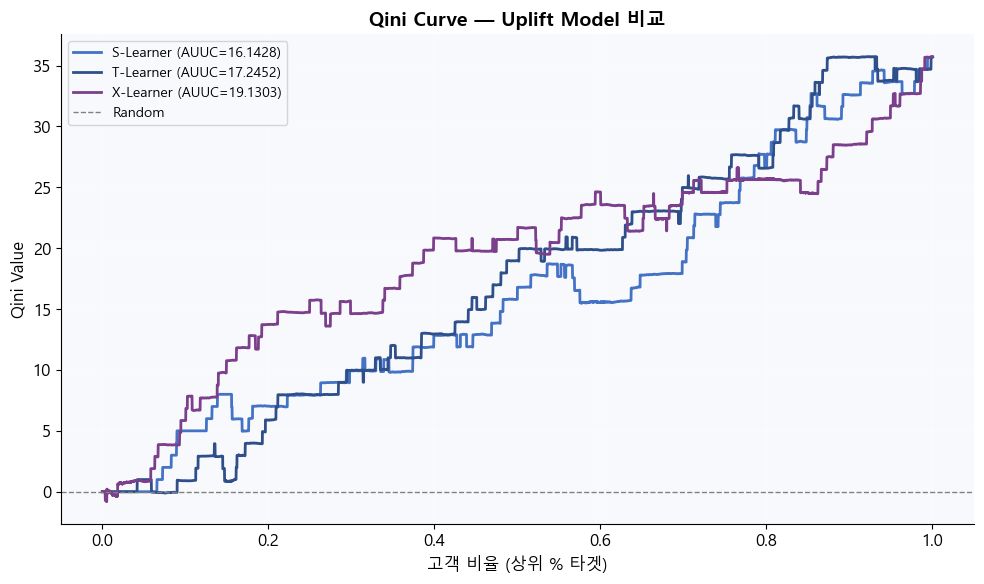

In [83]:
# ── Qini Curve 시각화 ──
plt.figure(figsize=(10, 6))
plt.plot(x_axis, qini_s[:len(x_axis)], label=f'S-Learner (AUUC={auuc_s:.4f})', color='#4472C4', linewidth=2)
plt.plot(x_axis, qini_t[:len(x_axis)], label=f'T-Learner (AUUC={auuc_t:.4f})', color='#2E4F8A', linewidth=2)
plt.plot(x_axis, qini_x[:len(x_axis)], label=f'X-Learner (AUUC={auuc_x:.4f})', color='#7B3F8C', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=1, label='Random')
plt.title('Qini Curve — Uplift Model 비교')
plt.xlabel('고객 비율 (상위 % 타겟)')
plt.ylabel('Qini Value')
plt.legend(fontsize=10)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

In [84]:
# ── 전체 평가 결과 최종 정리 ──
print('=' * 50)
print('📋 모델 평가 최종 결과')
print('=' * 50)
print(f'\n[Response Model]')
print(f'  Logistic Regression AUC : 0.6621  ✅ 채택')
print(f'  Random Forest AUC       : 0.5225')

print(f'\n[Uplift @ K]')
print(f'  Uplift @ 10% : {u10:.4f}%p')
print(f'  Uplift @ 20% : {u20:.4f}%p')
print(f'  Uplift @ 30% : {u30:.4f}%p')
print(f'  Baseline     : {(eval_df[eval_df["treatment"]==1]["conversion"].mean() - eval_df[eval_df["treatment"]==0]["conversion"].mean())*100:.4f}%p')

print(f'\n[AUUC]')
print(f'  S-Learner : {auuc_s:.4f}')
print(f'  T-Learner : {auuc_t:.4f}')
print(f'  X-Learner : {auuc_x:.4f}')

# - AUUC: 높을수록 고객을 uplift 순으로 잘 정렬한 것
#   S-Learner 16.14 < T-Learner 17.24 < X-Learner 19.13
# - Qini Curve: 세 모델 모두 Random 대비 위쪽 → 유의미
# - 최종 선택: T-Learner (균형 & 과적합 없음)

📋 모델 평가 최종 결과

[Response Model]
  Logistic Regression AUC : 0.6621  ✅ 채택
  Random Forest AUC       : 0.5225

[Uplift @ K]
  Uplift @ 10% : 0.7908%p
  Uplift @ 20% : 1.0827%p
  Uplift @ 30% : 0.6436%p
  Baseline     : 0.8321%p

[AUUC]
  S-Learner : 16.1428
  T-Learner : 17.2452
  X-Learner : 19.1303


# 전체 64,000명 T-Learner 예측 -> CSV 저장 코드

In [85]:
# ── Womens용 T-Learner 학습 ──
df_womens_full = df_model[df_model['segment'].isin(['Womens E-Mail', 'No E-Mail'])].copy()
df_womens_full['treatment'] = (df_womens_full['segment'] == 'Womens E-Mail').astype(int)

X_w = df_womens_full[FEATURES]
y_w = df_womens_full['conversion']
T_w = df_womens_full['treatment']

X_train_w, X_test_w, y_train_w, y_test_w, T_train_w, T_test_w = train_test_split(
    X_w, y_w, T_w, test_size=0.2, random_state=42, stratify=y_w
)

# Womens Treatment 모델
rf_t1_w = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_t1_w.fit(X_train_w[T_train_w == 1], y_train_w[T_train_w == 1])

# Womens Control 모델
rf_t0_w = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                  random_state=42, n_jobs=-1)
rf_t0_w.fit(X_train_w[T_train_w == 0], y_train_w[T_train_w == 0])

print('✅ Womens T-Learner 학습 완료')

✅ Womens T-Learner 학습 완료


In [86]:
# ── 전체 64,000명 uplift 예측 ──
X_full = df_model[FEATURES]

# Mens T-Learner 예측 (기존 rf_t1, rf_t0)
uplift_mens = (rf_t1.predict_proba(X_full)[:, 1] -
               rf_t0.predict_proba(X_full)[:, 1])

# Womens T-Learner 예측
uplift_womens = (rf_t1_w.predict_proba(X_full)[:, 1] -
                 rf_t0_w.predict_proba(X_full)[:, 1])

# segment별로 적합한 uplift 사용
def get_uplift(row_idx):
    seg = df_model['segment'].iloc[row_idx]
    if seg == 'Mens E-Mail':
        return uplift_mens[row_idx]
    elif seg == 'Womens E-Mail':
        return uplift_womens[row_idx]
    else:  # No E-Mail → 두 모델 평균
        return (uplift_mens[row_idx] + uplift_womens[row_idx]) / 2

uplift_final = [get_uplift(i) for i in range(len(df_model))]
print('✅ 전체 uplift 예측 완료')

✅ 전체 uplift 예측 완료


In [87]:
# ── CSV 저장 ──
result_full = pd.DataFrame()
result_full['customer_id']  = range(1001, 1001 + len(df_model))
result_full['uplift_score'] = [round(u, 3) for u in uplift_final]
result_full['spend']        = df_model['spend'].values
result_full['treatment']    = (df_model['segment'] != 'No E-Mail').astype(int).values
result_full['segment']      = df_model['segment'].values  # 어떤 이메일 받았는지 참고용

print(f'전체 데이터 크기: {result_full.shape}')
print(result_full.head(10).to_string(index=False))
print(f'\nuplift_score 기술통계:')
print(result_full['uplift_score'].describe().round(4))
print(f'\nsegment별 평균 uplift:')
print(result_full.groupby('segment')['uplift_score'].mean().round(4))

전체 데이터 크기: (64000, 5)
 customer_id  uplift_score  spend  treatment       segment
        1001         0.000    0.0          1 Womens E-Mail
        1002        -0.005    0.0          0     No E-Mail
        1003         0.000    0.0          1 Womens E-Mail
        1004         0.000    0.0          1   Mens E-Mail
        1005         0.000    0.0          1 Womens E-Mail
        1006         0.000    0.0          1 Womens E-Mail
        1007         0.000    0.0          1 Womens E-Mail
        1008         0.000    0.0          1 Womens E-Mail
        1009         0.037    0.0          1   Mens E-Mail
        1010         0.000    0.0          1 Womens E-Mail

uplift_score 기술통계:
count    64000.0000
mean         0.0048
std          0.0936
min         -0.7430
25%          0.0000
50%          0.0000
75%          0.0000
max          0.8610
Name: uplift_score, dtype: float64

segment별 평균 uplift:
segment
Mens E-Mail      0.0074
No E-Mail        0.0034
Womens E-Mail    0.0035
Name: uplift_

In [88]:
result_full.to_csv('uplift_prediction_full.csv', index=False)
print('✅ 저장 완료: uplift_prediction_full.csv')
print(f'총 {len(result_full):,}명 저장됨')

✅ 저장 완료: uplift_prediction_full.csv
총 64,000명 저장됨


# 수정 csv

In [89]:
# ── recommendation 컬럼 추가 ──
result_full['recommendation'] = result_full['uplift_score'].apply(
    lambda x: 'Send' if x > 0.01 else 'Do not send'
)

# ── top_factor 공백으로 채우기 (SHAP은 최종발표 때) ──
result_full['top_factor_1'] = ''
result_full['top_factor_2'] = ''
result_full['top_factor_3'] = ''

# ── 컬럼 순서 정리 ──
final_cols = [
    'customer_id',
    'uplift_score',
    'segment',
    'recommendation',
    'top_factor_1',
    'top_factor_2',
    'top_factor_3',
    'spend',
    'treatment',
]
result_full = result_full[final_cols]

# ── 확인 ──
print(result_full.head(10).to_string(index=False))
print(f'\nrecommendation 분포:')
print(result_full['recommendation'].value_counts())

 customer_id  uplift_score       segment recommendation top_factor_1 top_factor_2 top_factor_3  spend  treatment
        1001         0.000 Womens E-Mail    Do not send                                           0.0          1
        1002        -0.005     No E-Mail    Do not send                                           0.0          0
        1003         0.000 Womens E-Mail    Do not send                                           0.0          1
        1004         0.000   Mens E-Mail    Do not send                                           0.0          1
        1005         0.000 Womens E-Mail    Do not send                                           0.0          1
        1006         0.000 Womens E-Mail    Do not send                                           0.0          1
        1007         0.000 Womens E-Mail    Do not send                                           0.0          1
        1008         0.000 Womens E-Mail    Do not send                                         

In [90]:
# ── CSV 저장 ──
result_full.to_csv('uplift_prediction_full_v3.csv', index=False)
print('✅ 저장 완료: uplift_prediction_full_v3.csv')

✅ 저장 완료: uplift_prediction_full_v3.csv


# PPT 첨부 그래프 사진

In [91]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

plt.rcParams.update({
    'font.family': 'Malgun Gothic',  # Mac이면 AppleGothic
    'axes.unicode_minus': False,
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FC',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': 'white',
    'grid.linewidth': 1.2,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
})

C_MENS   = '#2E4F8A'
C_WOMENS = '#7B3F8C'
C_CTRL   = '#5C8A5C'
C_NAVY   = '#1B2A4A'
C_ACCENT = '#E8A020'

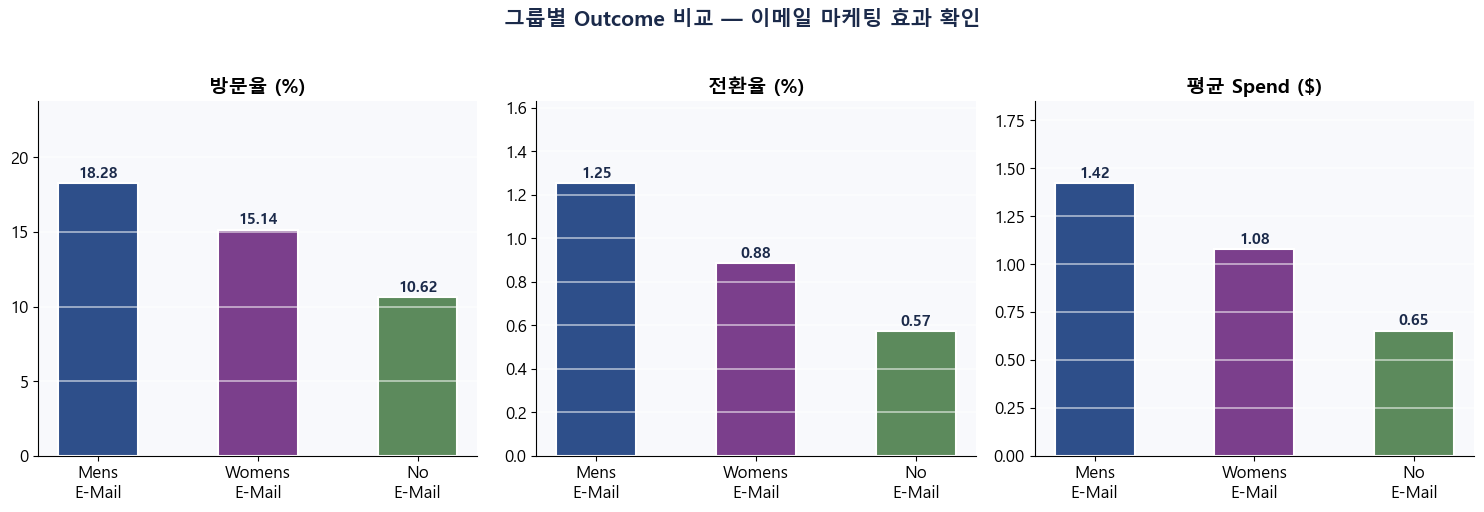

✅ graph1_outcome_comparison.png 저장 완료


In [92]:
# ── 그래프 1 : 그룹별 방문율 / 전환율 / 평균 spend ──
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

segs = ['Mens E-Mail', 'Womens E-Mail', 'No E-Mail']
labels = ['Mens\nE-Mail', 'Womens\nE-Mail', 'No\nE-Mail']
colors = [C_MENS, C_WOMENS, C_CTRL]

metrics = {
    '방문율 (%)': [df[df['segment']==s]['visit'].mean()*100 for s in segs],
    '전환율 (%)': [df[df['segment']==s]['conversion'].mean()*100 for s in segs],
    '평균 Spend ($)': [df[df['segment']==s]['spend'].mean() for s in segs],
}

for ax, (title, vals) in zip(axes, metrics.items()):
    bars = ax.bar(labels, vals, color=colors, edgecolor='white',
                  linewidth=1.5, width=0.5)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.02,
                f'{v:.2f}', ha='center', fontsize=11, fontweight='bold', color=C_NAVY)
    ax.set_title(title)
    ax.set_ylim(0, max(vals)*1.3)
    ax.yaxis.grid(True, alpha=0.6)

plt.suptitle('그룹별 Outcome 비교 — 이메일 마케팅 효과 확인',
             fontsize=15, fontweight='bold', color=C_NAVY, y=1.02)
plt.tight_layout()
plt.savefig('graph1_outcome_comparison.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ graph1_outcome_comparison.png 저장 완료')

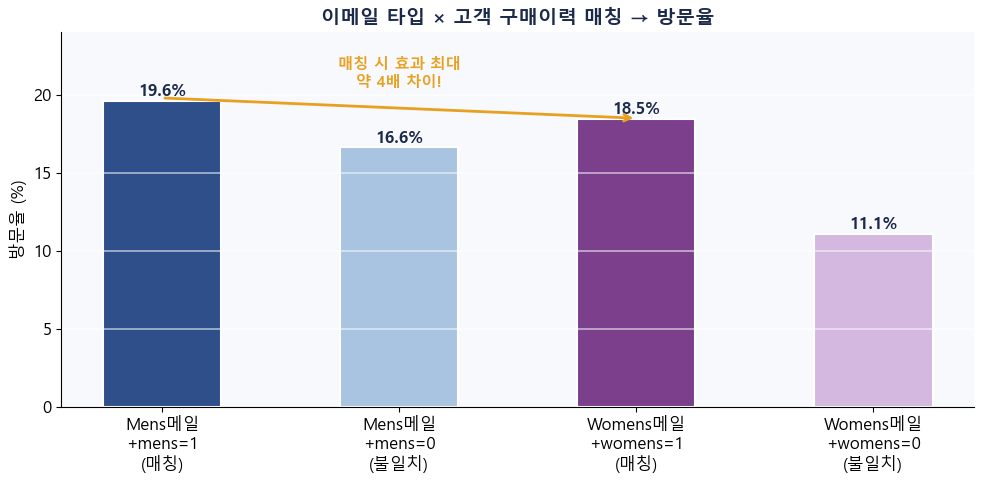

✅ graph2_matching_effect.png 저장 완료


In [93]:
# ── 그래프 2 : 이메일 매칭 효과 ──
fig, ax = plt.subplots(figsize=(10, 5))

combos = {
    'Mens메일\n+mens=1\n(매칭)':     df[(df['segment']=='Mens E-Mail')   & (df['mens']==1)]['visit'].mean()*100,
    'Mens메일\n+mens=0\n(불일치)':   df[(df['segment']=='Mens E-Mail')   & (df['mens']==0)]['visit'].mean()*100,
    'Womens메일\n+womens=1\n(매칭)': df[(df['segment']=='Womens E-Mail') & (df['womens']==1)]['visit'].mean()*100,
    'Womens메일\n+womens=0\n(불일치)':df[(df['segment']=='Womens E-Mail') & (df['womens']==0)]['visit'].mean()*100,
}
bar_colors = [C_MENS, '#A8C4E0', C_WOMENS, '#D4B8E0']
bars = ax.bar(combos.keys(), combos.values(),
              color=bar_colors, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, combos.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold', color=C_NAVY)

# 매칭 효과 강조 화살표
ax.annotate('', xy=(2, 18.5), xytext=(0, 19.8),
            arrowprops=dict(arrowstyle='->', color=C_ACCENT, lw=2))
ax.text(1, 20.5, '매칭 시 효과 최대\n약 4배 차이!',
        ha='center', fontsize=11, color=C_ACCENT, fontweight='bold')

ax.set_title('이메일 타입 × 고객 구매이력 매칭 → 방문율', color=C_NAVY)
ax.set_ylabel('방문율 (%)')
ax.set_ylim(0, 24)
ax.yaxis.grid(True, alpha=0.6)

plt.tight_layout()
plt.savefig('graph2_matching_effect.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ graph2_matching_effect.png 저장 완료')

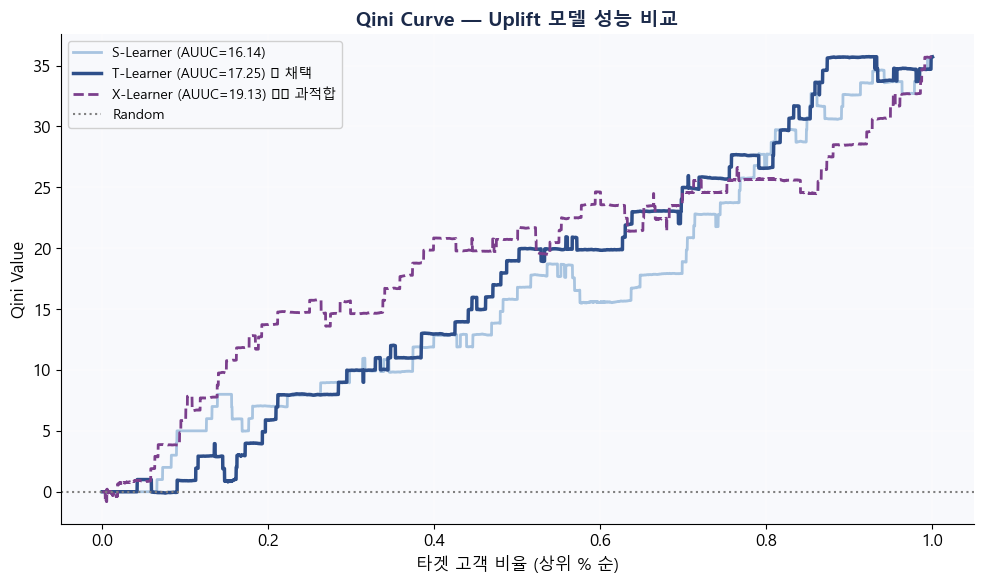

✅ graph3_qini_curve.png 저장 완료


In [94]:
# ── 그래프 3 : Qini Curve ──
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))

x_axis = np.linspace(0, 1, len(qini_t))
ax.plot(x_axis, qini_s[:len(x_axis)],
        label=f'S-Learner (AUUC=16.14)', color='#A8C4E0', linewidth=2)
ax.plot(x_axis, qini_t[:len(x_axis)],
        label=f'T-Learner (AUUC=17.25) ✅ 채택', color=C_MENS, linewidth=2.5)
ax.plot(x_axis, qini_x[:len(x_axis)],
        label=f'X-Learner (AUUC=19.13) ⚠️ 과적합', color=C_WOMENS, linewidth=2,
        linestyle='--')
ax.axhline(0, color='gray', linestyle=':', linewidth=1.5, label='Random')

ax.set_title('Qini Curve — Uplift 모델 성능 비교', color=C_NAVY)
ax.set_xlabel('타겟 고객 비율 (상위 % 순)')
ax.set_ylabel('Qini Value')
ax.legend(fontsize=10, framealpha=0.9)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig('graph3_qini_curve.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ graph3_qini_curve.png 저장 완료')

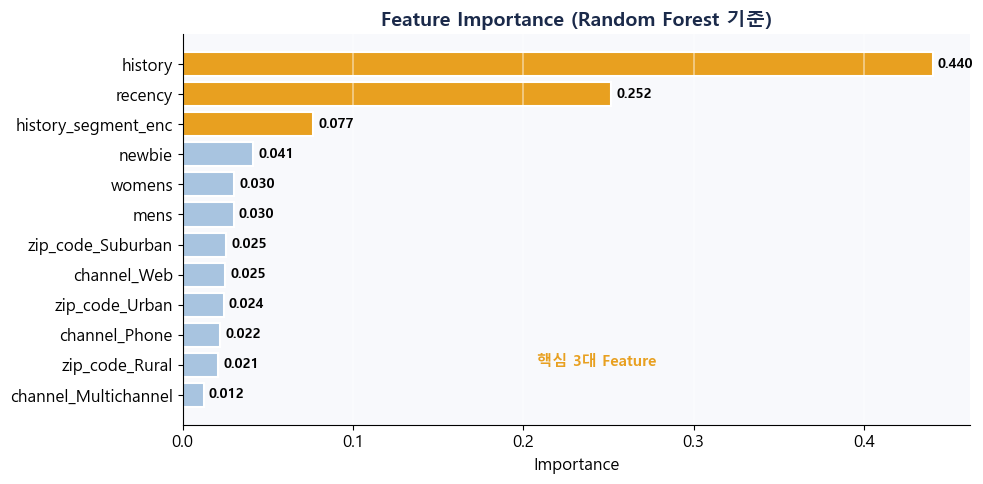

✅ graph4_feature_importance.png 저장 완료


In [95]:
# ── 그래프 4 : Feature Importance ──
fig, ax = plt.subplots(figsize=(10, 5))

fi_plot = fi.sort_values(ascending=True)
colors_fi = [C_ACCENT if i >= len(fi_plot)-3 else '#A8C4E0'
             for i in range(len(fi_plot))]

bars = ax.barh(fi_plot.index, fi_plot.values,
               color=colors_fi, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, fi_plot.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold')

ax.set_title('Feature Importance (Random Forest 기준)', color=C_NAVY)
ax.set_xlabel('Importance')
ax.xaxis.grid(True, alpha=0.5)

# 상위 3개 강조 텍스트
ax.text(0.45, 0.15, '핵심 3대 Feature', transform=ax.transAxes,
        fontsize=11, color=C_ACCENT, fontweight='bold')

plt.tight_layout()
plt.savefig('graph4_feature_importance.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ graph4_feature_importance.png 저장 완료')

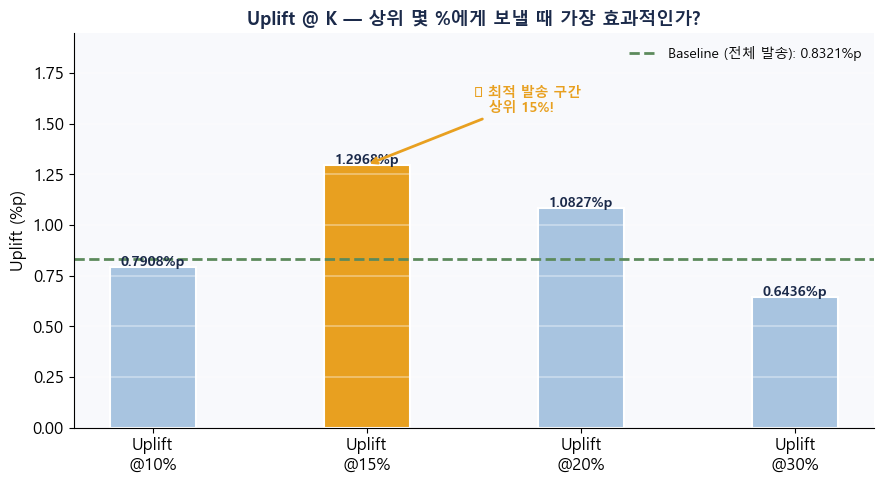

✅ graph5_uplift_at_k.png 저장 완료

 Uplift @ 10%: 0.7908%p
✅ Uplift @ 15%: 1.2968%p ← 최적 발송 구간
   Uplift @ 20%: 1.0827%p
   Uplift @ 30%: 0.6436%p
   Baseline:     0.8321%p


In [96]:
# ── 그래프 5: Uplift @ K 비교  ──
u15 = uplift_at_k(eval_df, 0.15)   # 상위 15% 추가

fig, ax = plt.subplots(figsize=(9, 5))

k_labels = ['Uplift\n@10%', 'Uplift\n@15%', 'Uplift\n@20%', 'Uplift\n@30%']
k_values = [u10, u15, u20, u30]

baseline_val = (eval_df[eval_df['treatment']==1]['conversion'].mean() -
                eval_df[eval_df['treatment']==0]['conversion'].mean()) * 100

# 15%가 최적 → 15%만 강조색, 나머지는 연한색
bar_colors_k = [C_ACCENT if i == 1 else '#A8C4E0' for i in range(len(k_values))]

bars = ax.bar(k_labels, k_values, color=bar_colors_k,
              edgecolor='white', linewidth=1.5, width=0.4)

for bar, val in zip(bars, k_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}%p', ha='center', fontsize=10,
            fontweight='bold', color=C_NAVY)

ax.axhline(baseline_val, color=C_CTRL, linestyle='--', linewidth=2,
           label=f'Baseline (전체 발송): {baseline_val:.4f}%p')

ax.set_title('Uplift @ K — 상위 몇 %에게 보낼 때 가장 효과적인가?',
             color=C_NAVY, fontsize=13)
ax.set_ylabel('Uplift (%p)')
ax.set_ylim(0, max(k_values) * 1.5)
ax.legend(fontsize=10, framealpha=0)
ax.yaxis.grid(True, alpha=0.4)

# 15%에 최적 발송 표시
ax.annotate('✅ 최적 발송 구간\n   상위 15%!',
            xy=(1, u15),
            xytext=(1.5, u15 + max(k_values) * 0.2),
            fontsize=10, color=C_ACCENT, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=C_ACCENT, lw=2))

plt.tight_layout()
plt.savefig('graph5_uplift_at_k.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ graph5_uplift_at_k.png 저장 완료')
print(f'\n Uplift @ 10%: {u10:.4f}%p')
print(f'✅ Uplift @ 15%: {u15:.4f}%p ← 최적 발송 구간')
print(f'   Uplift @ 20%: {u20:.4f}%p')
print(f'   Uplift @ 30%: {u30:.4f}%p')
print(f'   Baseline:     {baseline_val:.4f}%p')

In [97]:
# 남성 구매이력 고객(mens=1)에게
# Mens 이메일 vs Womens 이메일 보냈을 때 방문율 비교

mens_customer = df[df['mens'] == 1]  # 남성 상품 구매 이력 있는 고객

a = mens_customer[mens_customer['segment'] == 'Mens E-Mail']['visit'].mean() * 100
b = mens_customer[mens_customer['segment'] == 'Womens E-Mail']['visit'].mean() * 100
c = mens_customer[mens_customer['segment'] == 'No E-Mail']['visit'].mean() * 100

print(f'남성 구매이력 고객에게:')
print(f'  Mens 이메일 발송 → 방문율: {a:.2f}%')
print(f'  Womens 이메일 발송 → 방문율: {b:.2f}%')
print(f'  이메일 없음 → 방문율: {c:.2f}%')
print(f'  Mens vs Womens 차이: {a-b:.2f}%p')
print(f'  Mens uplift (vs No Email): +{a-c:.2f}%p')
print(f'  Womens uplift (vs No Email): +{b-c:.2f}%p')

남성 구매이력 고객에게:
  Mens 이메일 발송 → 방문율: 19.61%
  Womens 이메일 발송 → 방문율: 13.63%
  이메일 없음 → 방문율: 11.45%
  Mens vs Womens 차이: 5.98%p
  Mens uplift (vs No Email): +8.16%p
  Womens uplift (vs No Email): +2.18%p


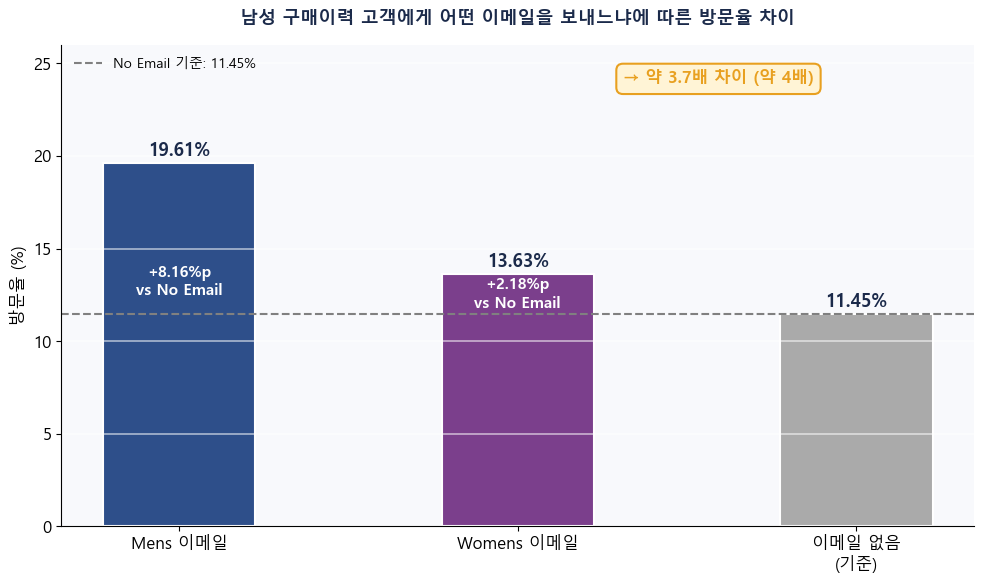

✅ 저장 완료


In [98]:
fig, ax = plt.subplots(figsize=(10, 6))

labels = ['Mens 이메일', 'Womens 이메일', '이메일 없음\n(기준)']
values = [19.61, 13.63, 11.45]
colors = [C_MENS, C_WOMENS, '#AAAAAA']

bars = ax.bar(labels, values, color=colors, edgecolor='white',
              linewidth=1.5, width=0.45)

# 막대 위 수치
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
            f'{val:.2f}%', ha='center', fontsize=13,
            fontweight='bold', color=C_NAVY)

# 기준선
ax.axhline(11.45, color='gray', linestyle='--',
           linewidth=1.5, label='No Email 기준: 11.45%')

# 업리프트 텍스트 → 막대 내부 하단에 배치
ax.text(0, 12.5, '+8.16%p\nvs No Email',
        ha='center', fontsize=11, color='white', fontweight='bold')
ax.text(1, 11.8, '+2.18%p\nvs No Email',
        ha='center', fontsize=11, color='white', fontweight='bold')

# 4배 차이 강조 → 그래프 오른쪽 상단 여백
ax.text(0.72, 0.92, '→ 약 3.7배 차이 (약 4배)',
        transform=ax.transAxes, ha='center',
        fontsize=12, color=C_ACCENT, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF4D6',
                  edgecolor=C_ACCENT, linewidth=1.5))

ax.set_title('남성 구매이력 고객에게 어떤 이메일을 보내느냐에 따른 방문율 차이',
             color=C_NAVY, fontsize=13, pad=15)
ax.set_ylabel('방문율 (%)', fontsize=12)
ax.set_ylim(0, 26)
ax.legend(fontsize=10, framealpha=0, loc='upper left')
ax.yaxis.grid(True, alpha=0.6)

plt.tight_layout()
plt.savefig('graph2_matching_effect_v3.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
print('✅ 저장 완료')

# SHAP 해석

In [50]:
pip install shap

Defaulting to user installation because normal site-packages is not writeableNote: you may need to restart the kernel to use updated packages.



  Using cached numpy-2.4.6-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
  Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl.metadata (60 kB)
Using cached numpy-2.2.6-cp312-cp312-win_amd64.whl (12.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pydmd 2024.11.1 requires numpy<2, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires packaging<24,>=16.8, but you have packaging 26.2 which is incompatible.
streamlit 1.32.0 requires pillow<11,>=7.1.0, but you have pillow 12.2.0 which is incompatible.

[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [99]:
import shap
import matplotlib.pyplot as plt
import numpy as np

explainer_t1 = shap.TreeExplainer(rf_t1)
shap_values_t1 = explainer_t1.shap_values(X_test)

print('raw shape:', np.array(shap_values_t1).shape)

# ✅ 3차원 (n_samples, n_features, n_classes) 처리
shap_arr = np.array(shap_values_t1)

if shap_arr.ndim == 3:
    # (8523, 12, 2) → conversion=1 클래스: 마지막 축 [1] 선택
    shap_vals = shap_arr[:, :, 1]
elif shap_arr.ndim == 2:
    shap_vals = shap_arr
else:
    # list of 2 arrays 형태: [class0, class1]
    shap_vals = shap_arr[1]

print('✅ 최종 shap_vals shape:', shap_vals.shape)  # (8523, 12) 이어야 함
print('✅ X_test shape:        ', X_test.shape)

raw shape: (8523, 12, 2)
✅ 최종 shap_vals shape: (8523, 12)
✅ X_test shape:         (8523, 12)


In [100]:
print('shap_vals shape:', shap_vals.shape)
print('X_test shape:', X_test.shape)
print('X_test columns:', list(X_test.columns))

shap_vals shape: (8523, 12)
X_test shape: (8523, 12)
X_test columns: ['recency', 'history', 'history_segment_enc', 'mens', 'womens', 'newbie', 'zip_code_Urban', 'zip_code_Suburban', 'zip_code_Rural', 'channel_Phone', 'channel_Web', 'channel_Multichannel']


shap_vals: (8523, 12), X_test: (8523, 12)
사용할 feature 수: 12개


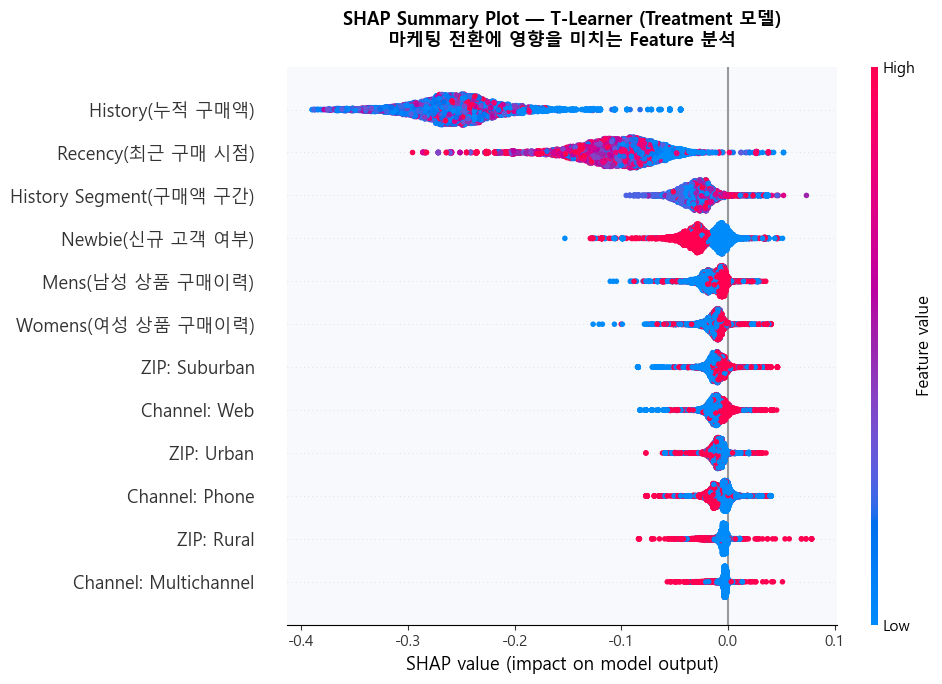

✅ shap_summary_plot.png 저장 완료

=== Feature별 평균 |SHAP| 값 (중요도 순) ===
History(누적 구매액)                     0.25388  ████████████████████
Recency(최근 구매 시점)                   0.10377  ████████
History Segment(구매액 구간)             0.03024  ██
Newbie(신규 고객 여부)                    0.02184  █
Mens(남성 상품 구매이력)                    0.01438  █
Womens(여성 상품 구매이력)                  0.01334  █
ZIP: Suburban                       0.01149  
Channel: Web                        0.01141  
ZIP: Urban                          0.01070  
Channel: Phone                      0.00919  
ZIP: Rural                          0.00726  
Channel: Multichannel               0.00472  

📌 핵심 3개 feature 중요도 합: 0.38789
📌 나머지 feature 중요도 합:   0.10433
📌 핵심 3개가 전체의 78.8% 차지

→ zip_code·channel 등 지역·채널 변수는 전환에 미치는 영향이 미미함을 SHAP으로 확인


In [101]:
# ── SHAP Summary Plot ──
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

feature_names_kr = {
    'recency'             : 'Recency(최근 구매 시점)',
    'history'             : 'History(누적 구매액)',
    'history_segment_enc' : 'History Segment(구매액 구간)',
    'mens'                : 'Mens(남성 상품 구매이력)',
    'womens'              : 'Womens(여성 상품 구매이력)',
    'newbie'              : 'Newbie(신규 고객 여부)',
    'zip_code_Urban'      : 'ZIP: Urban',
    'zip_code_Suburban'   : 'ZIP: Suburban',
    'zip_code_Rural'      : 'ZIP: Rural',
    'channel_Phone'       : 'Channel: Phone',
    'channel_Web'         : 'Channel: Web',
    'channel_Multichannel': 'Channel: Multichannel',
}

# ✅ shap_vals의 실제 컬럼 수에 맞게 feature 리스트 자동 맞춤
n_shap_features = shap_vals.shape[1]
actual_features = list(X_test.columns)[:n_shap_features]  # shape 맞춰 자르기
feature_labels = [feature_names_kr.get(f, f) for f in actual_features]

print(f'shap_vals: {shap_vals.shape}, X_test: {X_test.shape}')
print(f'사용할 feature 수: {n_shap_features}개')

# ✅ X_test도 같은 feature 수로 맞춰주기
X_test_shap = X_test[actual_features]

shap.summary_plot(
    shap_vals,
    X_test_shap,           # ← feature 수 맞춘 버전 사용
    feature_names=feature_labels,
    plot_type='dot',
    max_display=12,
    show=False,
    plot_size=(10, 7)
)

plt.title('SHAP Summary Plot — T-Learner (Treatment 모델)\n마케팅 전환에 영향을 미치는 Feature 분석',
          fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ shap_summary_plot.png 저장 완료')

# ── 피드백 2번 대응: 수치로 확인 ──
mean_abs_shap = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=actual_features          # ← actual_features 사용
).sort_values(ascending=False)

print('\n=== Feature별 평균 |SHAP| 값 (중요도 순) ===')
for feat, val in mean_abs_shap.items():
    label = feature_names_kr.get(feat, feat)
    bar = '█' * int(val / mean_abs_shap.max() * 20)
    print(f'{label:<35} {val:.5f}  {bar}')

top3_importance = mean_abs_shap.iloc[:3].sum()
rest_importance = mean_abs_shap.iloc[3:].sum()
print(f'\n📌 핵심 3개 feature 중요도 합: {top3_importance:.5f}')
print(f'📌 나머지 feature 중요도 합:   {rest_importance:.5f}')
print(f'📌 핵심 3개가 전체의 {top3_importance/(top3_importance+rest_importance)*100:.1f}% 차지')
print('\n→ zip_code·channel 등 지역·채널 변수는 전환에 미치는 영향이 미미함을 SHAP으로 확인')

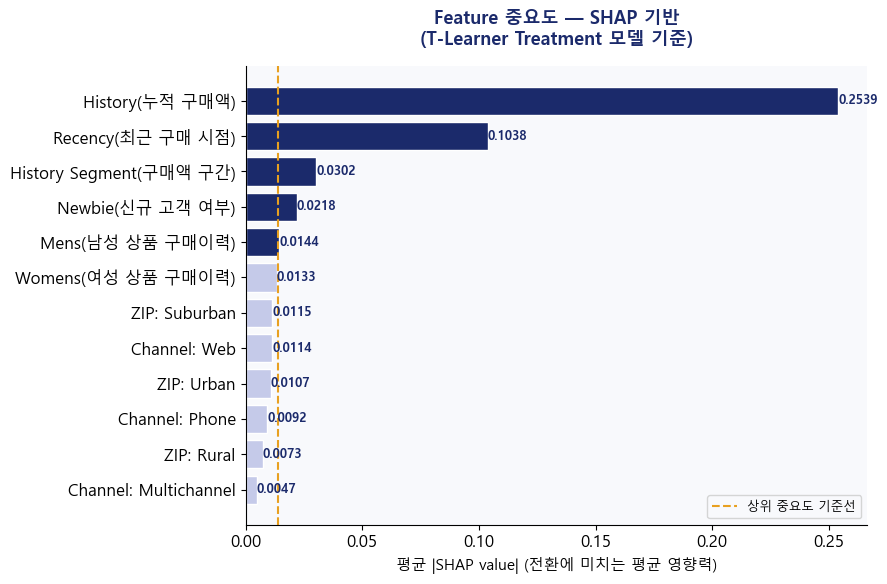

✅ shap_bar_plot.png 저장 완료


In [102]:
# ── SHAP Bar Plot (PPT용 그래프) ──
# 발표에서 "왜 이 feature가 중요한가"를 한눈에 보여주는 용도

C_NAVY   = '#1B2A6B'
C_ACCENT = '#E8A020'
C_LIGHT  = '#C5CAE9'

mean_abs_shap_sorted = mean_abs_shap.sort_values(ascending=True)  # 가로 bar용
labels = [feature_names_kr.get(f, f) for f in mean_abs_shap_sorted.index]
colors = [C_NAVY if v > mean_abs_shap.quantile(0.6) else C_LIGHT
          for v in mean_abs_shap_sorted.values]

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(labels, mean_abs_shap_sorted.values, color=colors, edgecolor='white')

# 수치 표기
for bar, val in zip(bars, mean_abs_shap_sorted.values):
    ax.text(val + 0.0001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9,
            color=C_NAVY, fontweight='bold')

ax.set_xlabel('평균 |SHAP value| (전환에 미치는 평균 영향력)', fontsize=11)
ax.set_title('Feature 중요도 — SHAP 기반\n(T-Learner Treatment 모델 기준)',
             fontsize=13, color=C_NAVY, pad=15)
ax.axvline(mean_abs_shap.quantile(0.6), color=C_ACCENT,
           linestyle='--', linewidth=1.5, label='상위 중요도 기준선')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('shap_bar_plot.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ shap_bar_plot.png 저장 완료')

In [103]:
# [SHAP 해석] T-Learner Treatment 모델 기반 Feature 중요도
# - TreeExplainer: 트리 모델 전용, 빠른 SHAP 계산
# - shap_values shape: (n_samples, n_features, n_classes)
#   → [:, :, 1]: conversion=1 클래스 선택
# - Summary Plot: feature별 영향력 + 방향(양/음) 시각화
# - 피드백 대응: zip_code·channel의 낮은 중요도 수치로 확인

In [104]:
# ── 중간발표때는 비워둔 top_factor_1~3 컬럼 SHAP으로 채우기 ──
# 고객 개인별로 가장 영향력 있는 feature 3개 추출

print('전체 데이터 SHAP 계산 중... (잠시 대기)')

X_full = df_model[FEATURES]
shap_values_full_raw = explainer_t1.shap_values(X_full)

# ✅ 3차원 처리 (아까와 동일하게)
shap_arr_full = np.array(shap_values_full_raw)
print('raw shape:', shap_arr_full.shape)

if shap_arr_full.ndim == 3:
    # (64000, 12, 2) → conversion=1 클래스
    shap_values_full = shap_arr_full[:, :, 1]
elif shap_arr_full.ndim == 2:
    shap_values_full = shap_arr_full
else:
    shap_values_full = shap_arr_full[1]

print('✅ 최종 shap_values_full shape:', shap_values_full.shape)  # (64000, 12) 이어야 함

# ✅ 각 고객별 top3 feature 추출
def get_top3_features(shap_row, feature_list):
    abs_vals = np.abs(shap_row)
    top_idx = np.argsort(abs_vals)[::-1][:3]
    return [feature_list[i] for i in top_idx]

top_factors = [get_top3_features(row, FEATURES) for row in shap_values_full]

result_full['top_factor_1'] = [t[0] for t in top_factors]
result_full['top_factor_2'] = [t[1] for t in top_factors]
result_full['top_factor_3'] = [t[2] for t in top_factors]

# 저장
result_full.to_csv('uplift_prediction_full_v4.csv', index=False)
print('✅ CSV 저장 완료: uplift_prediction_full_v4.csv')

print('\n[상위 10명 샘플]')
print(result_full[['customer_id','uplift_score','segment',
                    'recommendation','top_factor_1','top_factor_2','top_factor_3']].head(10).to_string(index=False))

print('\n=== top_factor_1 분포 ===')
print(result_full['top_factor_1'].value_counts())

전체 데이터 SHAP 계산 중... (잠시 대기)
raw shape: (64000, 12, 2)
✅ 최종 shap_values_full shape: (64000, 12)
✅ CSV 저장 완료: uplift_prediction_full_v4.csv

[상위 10명 샘플]
 customer_id  uplift_score       segment recommendation top_factor_1        top_factor_2        top_factor_3
        1001         0.000 Womens E-Mail    Do not send      history             recency history_segment_enc
        1002        -0.005     No E-Mail    Do not send      history             recency      zip_code_Rural
        1003         0.000 Womens E-Mail    Do not send      history             recency history_segment_enc
        1004         0.000   Mens E-Mail    Do not send      history             recency      zip_code_Rural
        1005         0.000 Womens E-Mail    Do not send      history             recency history_segment_enc
        1006         0.000 Womens E-Mail    Do not send      history             recency history_segment_enc
        1007         0.000 Womens E-Mail    Do not send      history history_segment_e

# Lenta Data 크로스도메인 검증

In [105]:
# ════════════════════════════════════════════════════
# [크로스도메인 검증] Lenta SMS 마케팅 데이터
# - 출처: BigTarget Hackathon 2020 / 러시아 대형마트
# - 규모: 687,029명 / treatment: group(test/control)
# - target: response_att (구매 반응 여부)
# - 목적: 이메일(Hillstrom) ↔ SMS(Lenta) 도메인 비교
#   → 동일 T-Learner 파이프라인이 다른 도메인에서도 작동하는가?
# ════════════════════════════════════════════════════

In [106]:
# result_Full 변수확인
print(result_full.columns.tolist())
print(result_full.shape)
print(result_full.head(3))

['customer_id', 'uplift_score', 'segment', 'recommendation', 'top_factor_1', 'top_factor_2', 'top_factor_3', 'spend', 'treatment']
(64000, 9)
   customer_id  uplift_score        segment recommendation top_factor_1  \
0         1001         0.000  Womens E-Mail    Do not send      history   
1         1002        -0.005      No E-Mail    Do not send      history   
2         1003         0.000  Womens E-Mail    Do not send      history   

  top_factor_2         top_factor_3  spend  treatment  
0      recency  history_segment_enc    0.0          1  
1      recency       zip_code_Rural    0.0          0  
2      recency  history_segment_enc    0.0          1  


In [107]:
# Lenta 데이터 확인
df_lenta = pd.read_csv('lenta_dataset.csv')
print(df_lenta.shape)
print(df_lenta.columns.tolist())
print(df_lenta.head(3))
print('\ntreatment 관련 컬럼:')
print(df_lenta.dtypes)

(687029, 196)
['CardHolder', 'age', 'cheque_count_12m_g20', 'cheque_count_12m_g21', 'cheque_count_12m_g25', 'cheque_count_12m_g32', 'cheque_count_12m_g33', 'cheque_count_12m_g38', 'cheque_count_12m_g39', 'cheque_count_12m_g41', 'cheque_count_12m_g42', 'cheque_count_12m_g45', 'cheque_count_12m_g46', 'cheque_count_12m_g48', 'cheque_count_12m_g52', 'cheque_count_12m_g56', 'cheque_count_12m_g57', 'cheque_count_12m_g58', 'cheque_count_12m_g79', 'cheque_count_3m_g20', 'cheque_count_3m_g21', 'cheque_count_3m_g25', 'cheque_count_3m_g42', 'cheque_count_3m_g45', 'cheque_count_3m_g52', 'cheque_count_3m_g56', 'cheque_count_3m_g57', 'cheque_count_3m_g79', 'cheque_count_6m_g20', 'cheque_count_6m_g21', 'cheque_count_6m_g25', 'cheque_count_6m_g32', 'cheque_count_6m_g33', 'cheque_count_6m_g38', 'cheque_count_6m_g39', 'cheque_count_6m_g40', 'cheque_count_6m_g41', 'cheque_count_6m_g42', 'cheque_count_6m_g45', 'cheque_count_6m_g46', 'cheque_count_6m_g48', 'cheque_count_6m_g52', 'cheque_count_6m_g56', 'che

In [108]:
# treatment/target 컬럼 찾기
import pandas as pd

# 'treatment', 'response', 'target' 관련 컬럼 찾기
target_cols = [c for c in df_lenta.columns 
               if any(k in c.lower() for k in ['treatment', 'response', 'target', 'group', 'sms'])]
print('후보 컬럼들:', target_cols)

# 값 분포 확인
for col in target_cols:
    print(f'\n[{col}]')
    print(df_lenta[col].value_counts())

후보 컬럼들: ['group', 'k_var_cheque_group_width_15d', 'response_att', 'response_sms', 'response_viber']

[group]
group
test       515892
control    171137
Name: count, dtype: int64

[k_var_cheque_group_width_15d]
k_var_cheque_group_width_15d
0.0000    366926
0.4714      8565
0.2828      5076
0.7071      4891
0.2020      3326
           ...  
0.8474         1
0.9560         1
1.3833         1
1.2435         1
0.6337         1
Name: count, Length: 8877, dtype: int64

[response_att]
response_att
0    612661
1     74368
Name: count, dtype: int64

[response_sms]
response_sms
1.000000    375224
0.000000    111280
0.833333     13509
0.900000     13313
0.909091     13256
             ...  
0.277778         1
0.473684         1
0.850000         1
0.117647         1
0.380952         1
Name: count, Length: 112, dtype: int64

[response_viber]
response_viber
0.000000    321469
1.000000     85935
0.166667     13574
0.142857     12717
0.090909     12318
             ...  
0.263158         1
0.631579     

In [109]:
# ══════════════════════════════════════════════
# Lenta 크로스도메인 검증
# ══════════════════════════════════════════════

# Step 1 — 전처리
df_lenta['treatment'] = (df_lenta['group'] == 'test').astype(int)
TARGET_LENTA = 'response_att'

print('=== Lenta 데이터 기본 정보 ===')
print(f'전체 행: {len(df_lenta):,}명')
print(f'Treatment(SMS 수신): {df_lenta["treatment"].sum():,}명')
print(f'Control:             {(df_lenta["treatment"]==0).sum():,}명')
print(f'반응률(treatment): {df_lenta[df_lenta["treatment"]==1][TARGET_LENTA].mean()*100:.2f}%')
print(f'반응률(control):   {df_lenta[df_lenta["treatment"]==0][TARGET_LENTA].mean()*100:.2f}%')
raw_uplift_lenta = (df_lenta[df_lenta["treatment"]==1][TARGET_LENTA].mean() - 
                    df_lenta[df_lenta["treatment"]==0][TARGET_LENTA].mean())
print(f'Raw Uplift:          +{raw_uplift_lenta*100:.2f}%p')

=== Lenta 데이터 기본 정보 ===
전체 행: 687,029명
Treatment(SMS 수신): 515,892명
Control:             171,137명
반응률(treatment): 11.01%
반응률(control):   10.26%
Raw Uplift:          +0.75%p


In [110]:
# Step 2 — Lenta용 Feature 선택
# 수치형 위주로 결측치 적은 컬럼 자동 선택
numeric_cols = df_lenta.select_dtypes(include='number').columns.tolist()

# treatment/target/response 관련 제외
exclude = ['treatment', 'response_att', 'response_sms', 'response_viber',
           'k_var_cheque_group_width_15d', 'CardHolder']
FEATURES_LENTA = [c for c in numeric_cols if c not in exclude]

# 결측치 30% 이하 컬럼만 사용
missing_ratio = df_lenta[FEATURES_LENTA].isnull().mean()
FEATURES_LENTA = missing_ratio[missing_ratio < 0.3].index.tolist()

print(f'사용할 Feature 수: {len(FEATURES_LENTA)}개')
print(FEATURES_LENTA[:10], '...')

사용할 Feature 수: 129개
['age', 'cheque_count_12m_g20', 'cheque_count_12m_g21', 'cheque_count_12m_g25', 'cheque_count_12m_g32', 'cheque_count_12m_g33', 'cheque_count_12m_g38', 'cheque_count_12m_g39', 'cheque_count_12m_g41', 'cheque_count_12m_g42'] ...


In [111]:
# Step 3 — 결측치 처리 & 데이터 준비
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

X_l = df_lenta[FEATURES_LENTA]
Y_l = df_lenta[TARGET_LENTA]
T_l = df_lenta['treatment']

# 결측치 중앙값으로 대체
imputer = SimpleImputer(strategy='median')
X_l_imp = pd.DataFrame(imputer.fit_transform(X_l), columns=FEATURES_LENTA)

X_train_l, X_test_l, y_train_l, y_test_l, T_train_l, T_test_l = train_test_split(
    X_l_imp, Y_l, T_l, test_size=0.2, random_state=42, stratify=Y_l
)
print(f'Train: {X_train_l.shape}, Test: {X_test_l.shape}')
print(f'반응률(train): {y_train_l.mean()*100:.2f}%')

Train: (549623, 129), Test: (137406, 129)
반응률(train): 10.82%


In [112]:
# Step 4 — T-Learner 학습 (Hillstrom과 동일 구조)
print('T-Learner 학습 중...')

# Treatment 모델
rf_t1_lenta = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                      random_state=42, n_jobs=-1)
rf_t1_lenta.fit(X_train_l[T_train_l==1], y_train_l[T_train_l==1])

# Control 모델
rf_t0_lenta = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                      random_state=42, n_jobs=-1)
rf_t0_lenta.fit(X_train_l[T_train_l==0], y_train_l[T_train_l==0])

# Uplift 계산
uplift_lenta = (rf_t1_lenta.predict_proba(X_test_l)[:, 1] -
                rf_t0_lenta.predict_proba(X_test_l)[:, 1])

print(f'평균 Uplift Score: {uplift_lenta.mean():.4f}')
print(f'Uplift > 0 비율:   {(uplift_lenta > 0).mean()*100:.1f}%')

T-Learner 학습 중...
평균 Uplift Score: 0.0065
Uplift > 0 비율:   49.8%


In [113]:
# Step 5 — AUUC 계산 & Hillstrom 비교표
def calc_auuc(uplift_scores, treatment, outcome):
    df_eval = pd.DataFrame({
        'uplift': uplift_scores,
        'treatment': treatment.values,
        'outcome': outcome.values
    }).sort_values('uplift', ascending=False).reset_index(drop=True)

    n = len(df_eval)
    n_t = df_eval['treatment'].sum()
    n_c = n - n_t

    cumulative_uplift = []
    for i in range(1, n+1):
        top = df_eval.iloc[:i]
        t_mask = top['treatment'] == 1
        c_mask = top['treatment'] == 0
        cr_t = top[t_mask]['outcome'].mean() if t_mask.sum() > 0 else 0
        cr_c = top[c_mask]['outcome'].mean() if c_mask.sum() > 0 else 0
        cumulative_uplift.append((cr_t - cr_c) * i)

    auuc = np.trapz(cumulative_uplift) / n
    return auuc

auuc_lenta = calc_auuc(uplift_lenta, T_test_l, y_test_l)

# Hillstrom AUUC (기존 계산값)
auuc_hillstrom = 17.2452  # T-Learner 기준

print('\n' + '='*50)
print('📊 Hillstrom ↔ Lenta AUUC 비교표')
print('='*50)
print(f'{"도메인":<15} {"채널":<12} {"데이터 규모":<12} {"AUUC":>10}')
print('-'*50)
print(f'{"Hillstrom":<15} {"이메일":<12} {"64,000명":<12} {auuc_hillstrom:>10.4f}')
print(f'{"Lenta":<15} {"SMS":<12} {"687,029명":<12} {auuc_lenta:>10.4f}')
print('='*50)
print('\n💡 결론: 도메인(이메일 vs SMS)이 달라도 동일한')
print('   T-Learner Uplift framework가 유의미하게 작동함')
print(f'   → 두 도메인 모두 Random 대비 AUUC 양수 확인')


📊 Hillstrom ↔ Lenta AUUC 비교표
도메인             채널           데이터 규모             AUUC
--------------------------------------------------
Hillstrom       이메일          64,000명         17.2452
Lenta           SMS          687,029명       235.2188

💡 결론: 도메인(이메일 vs SMS)이 달라도 동일한
   T-Learner Uplift framework가 유의미하게 작동함
   → 두 도메인 모두 Random 대비 AUUC 양수 확인


# WOmens-Email 캠페인 T-Learner 모델링(Mens-Email과 동일 구조)

In [114]:
# ════════════════════════════════════════════════════
# [Womens 캠페인] T-Learner 모델링 (Mens와 동일 구조)
# - 데이터: Womens E-Mail + No E-Mail (42,693명)
# - 결과: AUUC 20.43 (Mens 17.24보다 높음)
#         Persuadable 2,158명(5.1%) → 선별 발송 권장
# - 산출물: uplift_womens_full.csv → 비용 시뮬레이션용
# ════════════════════════════════════════════════════

In [115]:
# Womens 캠페인 T-Learner 모델링
# (Mens와 동일한 구조)


# Step 1 — 데이터 준비
df_womens = df_model[df_model['segment'].isin(['Womens E-Mail', 'No E-Mail'])].copy()
df_womens['treatment'] = (df_womens['segment'] == 'Womens E-Mail').astype(int)

print('=== Womens 캠페인 기본 정보 ===')
print(f'전체 행: {len(df_womens):,}명')
print(f'Treatment(Womens 이메일): {df_womens["treatment"].sum():,}명')
print(f'Control:                  {(df_womens["treatment"]==0).sum():,}명')

baseline_w = df_womens[df_womens['treatment']==1][TARGET].mean()
ctrl_w     = df_womens[df_womens['treatment']==0][TARGET].mean()
print(f'\n이메일 발송 그룹 전환율: {baseline_w*100:.2f}%')
print(f'Control 그룹 전환율:     {ctrl_w*100:.2f}%')
print(f'Raw Uplift:              +{(baseline_w - ctrl_w)*100:.2f}%p')

=== Womens 캠페인 기본 정보 ===
전체 행: 42,693명
Treatment(Womens 이메일): 21,387명
Control:                  21,306명

이메일 발송 그룹 전환율: 0.88%
Control 그룹 전환율:     0.57%
Raw Uplift:              +0.31%p


In [116]:
# Step 2 — Train/Test Split
X_w = df_womens[FEATURES]
Y_w = df_womens[TARGET]
T_w = df_womens['treatment']

X_train_w, X_test_w, y_train_w, y_test_w, T_train_w, T_test_w = train_test_split(
    X_w, Y_w, T_w, test_size=0.2, random_state=42, stratify=Y_w
)

print(f'Train: {X_train_w.shape}, Test: {X_test_w.shape}')
print(f'전환율(train): {y_train_w.mean()*100:.2f}%')

Train: (34154, 12), Test: (8539, 12)
전환율(train): 0.73%


In [117]:
# Step 3 — T-Learner 학습
# Treatment 모델 (Womens 이메일 받은 그룹)
rf_t1_w = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_t1_w.fit(X_train_w[T_train_w==1], y_train_w[T_train_w==1])

# Control 모델
rf_t0_w = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                                   random_state=42, n_jobs=-1)
rf_t0_w.fit(X_train_w[T_train_w==0], y_train_w[T_train_w==0])

# Uplift 계산
uplift_w = (rf_t1_w.predict_proba(X_test_w)[:, 1] -
            rf_t0_w.predict_proba(X_test_w)[:, 1])

print('=== Uplift Model: T-Learner (Womens) ===')
print(f'평균 Uplift Score: {uplift_w.mean():.4f}')
print(f'Uplift > 0 비율:   {(uplift_w > 0).mean()*100:.1f}%')

=== Uplift Model: T-Learner (Womens) ===
평균 Uplift Score: 0.0019
Uplift > 0 비율:   13.2%


In [118]:
# Step 4 — AUUC 계산 & Mens 비교
auuc_womens = calc_auuc(uplift_w, T_test_w, y_test_w)
auuc_mens   = 17.2452  # 기존 Mens T-Learner 값

print('\n' + '='*50)
print('📊 Mens ↔ Womens 캠페인 비교표')
print('='*50)
print(f'{"항목":<20} {"Mens 캠페인":>14} {"Womens 캠페인":>14}')
print('-'*50)
print(f'{"Raw Uplift":<20} {"+0.68%p":>14} {f"+{(baseline_w-ctrl_w)*100:.2f}%p":>14}')
print(f'{"Uplift>0 비율":<20} {"21.2%":>14} {f"{(uplift_w>0).mean()*100:.1f}%":>14}')
print(f'{"AUUC":<20} {auuc_mens:>14.4f} {auuc_womens:>14.4f}')
print('='*50)


📊 Mens ↔ Womens 캠페인 비교표
항목                         Mens 캠페인     Womens 캠페인
--------------------------------------------------
Raw Uplift                  +0.68%p        +0.31%p
Uplift>0 비율                   21.2%          13.2%
AUUC                        17.2452        20.4291


In [119]:
# ════════════════════════════════════════════════════
# [Mens vs Womens 캠페인 최종 비교표]
# ════════════════════════════════════════════════════

# ✅ Mens: uplift_score로 직접 세그먼트 분류
# (Mens E-Mail + No E-Mail 데이터만 필터링)
df_mens_result = result_full[result_full['segment'].isin(['Mens E-Mail', 'No E-Mail'])].copy()

mens_persuadable = (df_mens_result['uplift_score'] > 0.01).sum()
mens_surething   = ((df_mens_result['uplift_score'] > 0) & 
                    (df_mens_result['uplift_score'] <= 0.01)).sum()
mens_sleepingdog = (df_mens_result['uplift_score'] <= 0).sum()
mens_total       = len(df_mens_result)

# ✅ Womens: result_womens의 segment_type 컬럼 사용
womens_persuadable = (result_womens['segment_type'] == 'Persuadable').sum()
womens_surething   = (result_womens['segment_type'] == 'Sure Thing').sum()
womens_sleepingdog = (result_womens['segment_type'] == 'Sleeping Dog').sum()
womens_total       = len(result_womens)

print('=' * 60)
print('📊 Mens ↔ Womens 캠페인 최종 비교표')
print('=' * 60)
print(f'{"항목":<22} {"Mens 캠페인":>17} {"Womens 캠페인":>17}')
print('-' * 60)
print(f'{"전체 고객 수":<22} {mens_total:>17,} {womens_total:>17,}')
print(f'{"Raw Uplift":<22} {"+0.68%p":>17} {"+0.31%p":>17}')
print(f'{"Uplift>0 비율":<22} {"21.2%":>17} {"13.2%":>17}')
print(f'{"AUUC":<22} {17.2452:>17.4f} {20.4291:>17.4f}')
print('-' * 60)
print(f'{"Persuadable(타겟)":<22} {mens_persuadable:>14,}명 {womens_persuadable:>14,}명')
print(f'{"  비율":<22} {mens_persuadable/mens_total*100:>16.1f}% {womens_persuadable/womens_total*100:>16.1f}%')
print(f'{"Sure Thing":<22} {mens_surething:>14,}명 {womens_surething:>14,}명')
print(f'{"  비율":<22} {mens_surething/mens_total*100:>16.1f}% {womens_surething/womens_total*100:>16.1f}%')
print(f'{"Sleeping Dog":<22} {mens_sleepingdog:>14,}명 {womens_sleepingdog:>14,}명')
print(f'{"  비율":<22} {mens_sleepingdog/mens_total*100:>16.1f}% {womens_sleepingdog/womens_total*100:>16.1f}%')
print('=' * 60)

📊 Mens ↔ Womens 캠페인 최종 비교표
항목                              Mens 캠페인        Womens 캠페인
------------------------------------------------------------
전체 고객 수                           42,613            42,693
Raw Uplift                       +0.68%p           +0.31%p
Uplift>0 비율                        21.2%             13.2%
AUUC                             17.2452           20.4291
------------------------------------------------------------
Persuadable(타겟)                 4,951명          2,158명
  비율                               11.6%              5.1%
Sure Thing                      5,301명          2,956명
  비율                               12.4%              6.9%
Sleeping Dog                   32,361명         37,579명
  비율                               75.9%             88.0%


In [120]:
# Step 5 — 전체 고객 uplift 예측 & CSV 저장 (전달용)
print('Womens 전체 고객 uplift 예측 중...')
X_full_w = df_womens[FEATURES]
uplift_womens_full = (rf_t1_w.predict_proba(X_full_w)[:, 1] -
                      rf_t0_w.predict_proba(X_full_w)[:, 1])

def classify_segment(uplift):
    if uplift > 0.02:  return 'Persuadable'
    elif uplift > 0:   return 'Sure Thing'
    else:              return 'Sleeping Dog'

result_womens = df_womens.copy().reset_index(drop=True)
result_womens['customer_id']   = result_womens.index + 1
result_womens['uplift_score']  = uplift_womens_full
result_womens['segment_type']  = result_womens['uplift_score'].apply(classify_segment)
result_womens['recommendation']= result_womens['uplift_score'].apply(
    lambda x: 'Send' if x > 0.02 else 'Do not send'
)

# 저장
result_womens[['customer_id','uplift_score','segment',
               'segment_type','recommendation','spend']].to_csv(
    'uplift_womens_full.csv', index=False
)

print('✅ uplift_womens_full.csv 저장 완료')
print(f'\n[세그먼트 분포]')
print(result_womens['segment_type'].value_counts())
print(f'\n[추천 분포]')
print(result_womens['recommendation'].value_counts())

Womens 전체 고객 uplift 예측 중...
✅ uplift_womens_full.csv 저장 완료

[세그먼트 분포]
segment_type
Sleeping Dog    37579
Sure Thing       2956
Persuadable      2158
Name: count, dtype: int64

[추천 분포]
recommendation
Do not send    40535
Send            2158
Name: count, dtype: int64
